**Probelem Statements**

**Predict the apple stock market price for the next 30 days. There are Open, High, Low and Close prices that have been given for each day starting from 2012 to 2019 for Apple stock**


Apple_stock_Forecast Machine Learning Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 300
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

Import the CSV data as pandas DataFrame

In [2]:
df = pd.read_csv(r"C:\Users\vimal\OneDrive\Desktop\Apple stock Forecast\NoteBook\data\AAPL.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


# EDA (Exploratory Data Analysis)

- Exploratory Data Analysis (EDA) is an approach to analyze the data using visual techniques and statistical techniques. It is used to discover trends, patterns, or to check assumptions with the help of statistical summary and graphical representations.

**Steps involved in EDA**
1. Describing the data
2. Data cleaning
3. Imputation techniques
4. Data analysis and visualization
5. Transformations
6. Auto EDA

In [3]:
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100
...,...,...,...,...,...,...,...
2006,2019-12-23,280.529999,284.250000,280.369995,284.000000,282.054138,24643000
2007,2019-12-24,284.690002,284.890015,282.920013,284.269989,282.322266,12119700
2008,2019-12-26,284.820007,289.980011,284.700012,289.910004,287.923645,23280300
2009,2019-12-27,291.119995,293.970001,288.119995,289.799988,287.814392,36566500


In [4]:
# Convert the 'Date' column to datetime
df["Date"] = pd.to_datetime(df["Date"])

In [5]:
#Summary of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2011 entries, 0 to 2010
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2011 non-null   datetime64[ns]
 1   Open       2011 non-null   float64       
 2   High       2011 non-null   float64       
 3   Low        2011 non-null   float64       
 4   Close      2011 non-null   float64       
 5   Adj Close  2011 non-null   float64       
 6   Volume     2011 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 110.1 KB


In [6]:
#set the 'Date' column as the index
df.set_index("Date", inplace=True)


In [7]:
#Descrptive summary of the dataset
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2.011000e+03
mean,126.707469,127.827594,125.580258,126.741235,119.505548,5.949670e+07
std,50.483753,50.926301,50.124940,50.578369,52.438444,4.683856e+07
min,55.424286,57.085712,55.014286,55.790001,48.921928,1.136200e+07
25%,85.882858,86.717858,85.056427,86.202145,75.056679,2.758565e+07
50%,113.050003,114.190002,111.870003,113.050003,105.222908,4.346900e+07
75%,165.190002,167.409996,163.424995,165.245002,160.047111,7.471030e+07
max,291.119995,293.970001,288.119995,291.519989,289.522614,3.765300e+08


In [8]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


In [9]:
df.shape

(2011, 6)

In [10]:
##List down all the columns names
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [11]:
df["Close"].unique()

array([ 58.747143,  59.062859,  59.718571, ..., 289.910004, 289.799988,
       291.519989])

In [12]:
df["Close"].value_counts()

Close
99.620003     3
126.599998    3
100.750000    3
97.339996     3
172.500000    3
             ..
90.360001     1
90.279999     1
90.830002     1
90.910004     1
291.519989    1
Name: count, Length: 1912, dtype: int64

In [13]:
## Missing values in the dataset

df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [14]:
##Duplicated records
df[df.duplicated()]

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


In [15]:
df.duplicated().sum()

0

In [16]:
df.dtypes

Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

# Drop columns

We need to get rid of all the uneccesary columns or else it will be very complex data.

In [17]:
df.drop(columns=["Adj Close"], inplace=True)

In [18]:
df

,Open,High,Low,Close,Volume
Date,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,75555200
2012-01-04,58.571430,59.240002,58.468571,59.062859,65005500
2012-01-05,59.278572,59.792858,58.952858,59.718571,67817400
2012-01-06,59.967144,60.392857,59.888573,60.342857,79573200
2012-01-09,60.785713,61.107143,60.192856,60.247143,98506100
...,...,...,...,...,...
2019-12-23,280.529999,284.250000,280.369995,284.000000,24643000
2019-12-24,284.690002,284.890015,282.920013,284.269989,12119700
2019-12-26,284.820007,289.980011,284.700012,289.910004,23280300


# Outlier detection

    - There are multiple approaches to detect outliers in the dataset.
        - Histogram
        - Boxplot
        - Descriptive stats for df

In [19]:
df.describe

<bound method NDFrame.describe of                   Open        High         Low       Close    Volume
Date                                                                
2012-01-03   58.485714   58.928570   58.428570   58.747143  75555200
2012-01-04   58.571430   59.240002   58.468571   59.062859  65005500
2012-01-05   59.278572   59.792858   58.952858   59.718571  67817400
2012-01-06   59.967144   60.392857   59.888573   60.342857  79573200
2012-01-09   60.785713   61.107143   60.192856   60.247143  98506100
...                ...         ...         ...         ...       ...
2019-12-23  280.529999  284.250000  280.369995  284.000000  24643000
2019-12-24  284.690002  284.890015  282.920013  284.269989  12119700
2019-12-26  284.820007  289.980011  284.700012  289.910004  23280300
2019-12-27  291.119995  293.970001  288.119995  289.799988  36566500
2019-12-30  289.459991  292.690002  285.220001  291.519989  36028600

[2011 rows x 5 columns]>

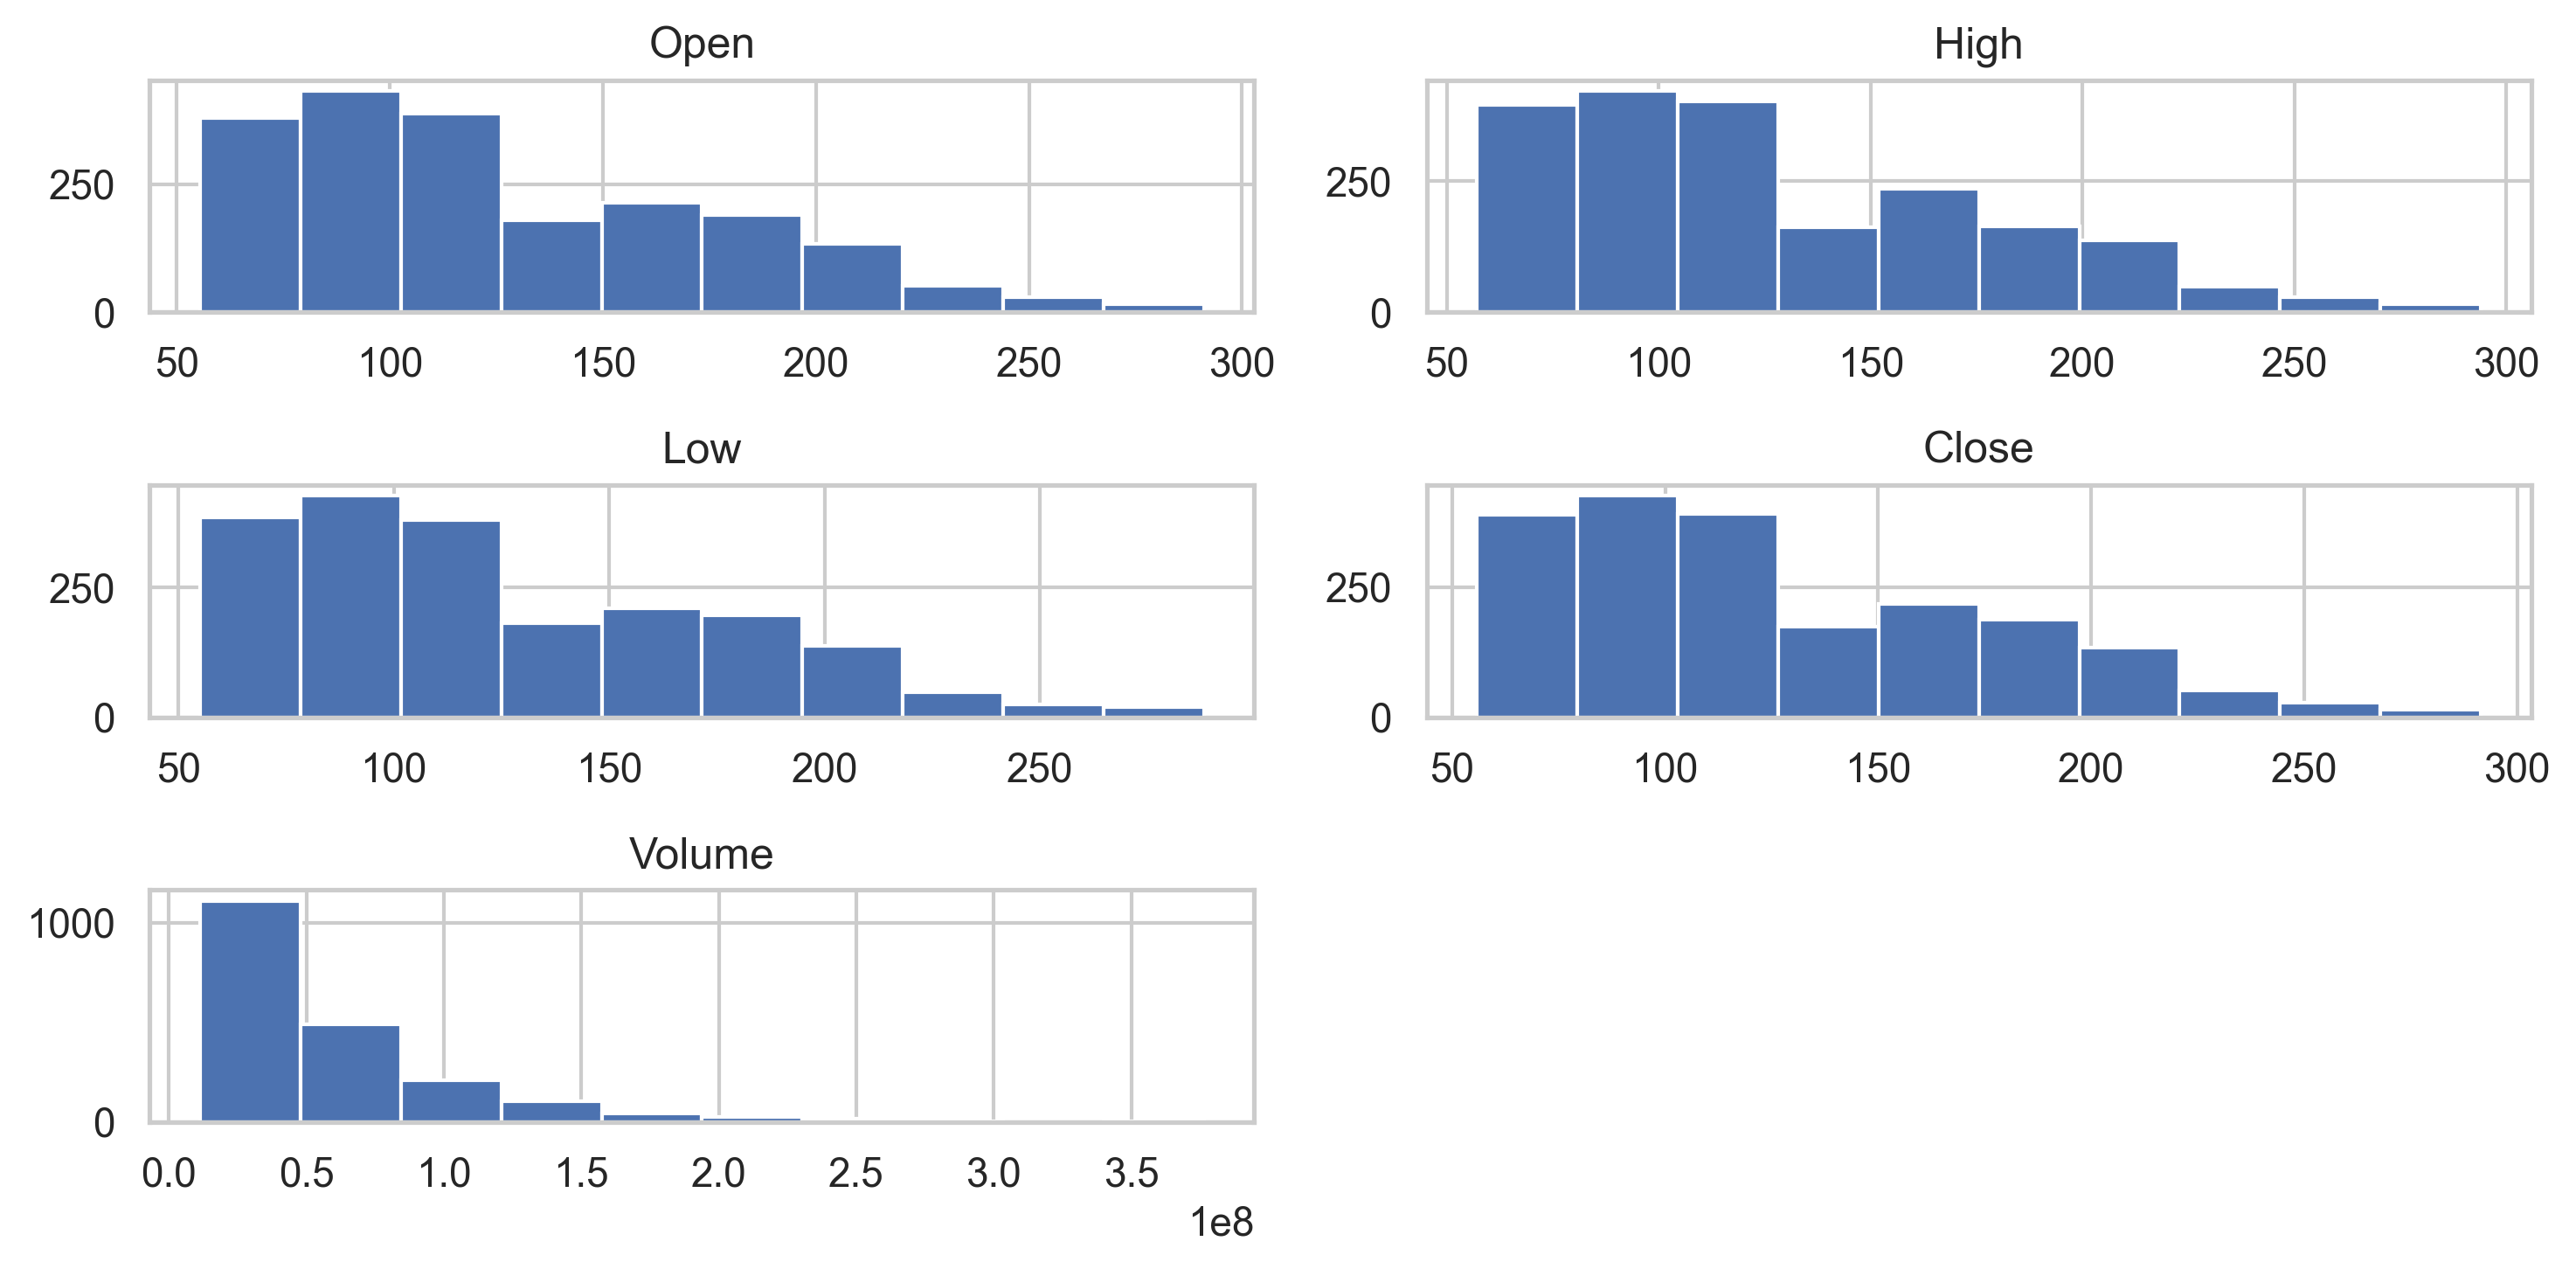

In [20]:
df.hist()
plt.tight_layout()

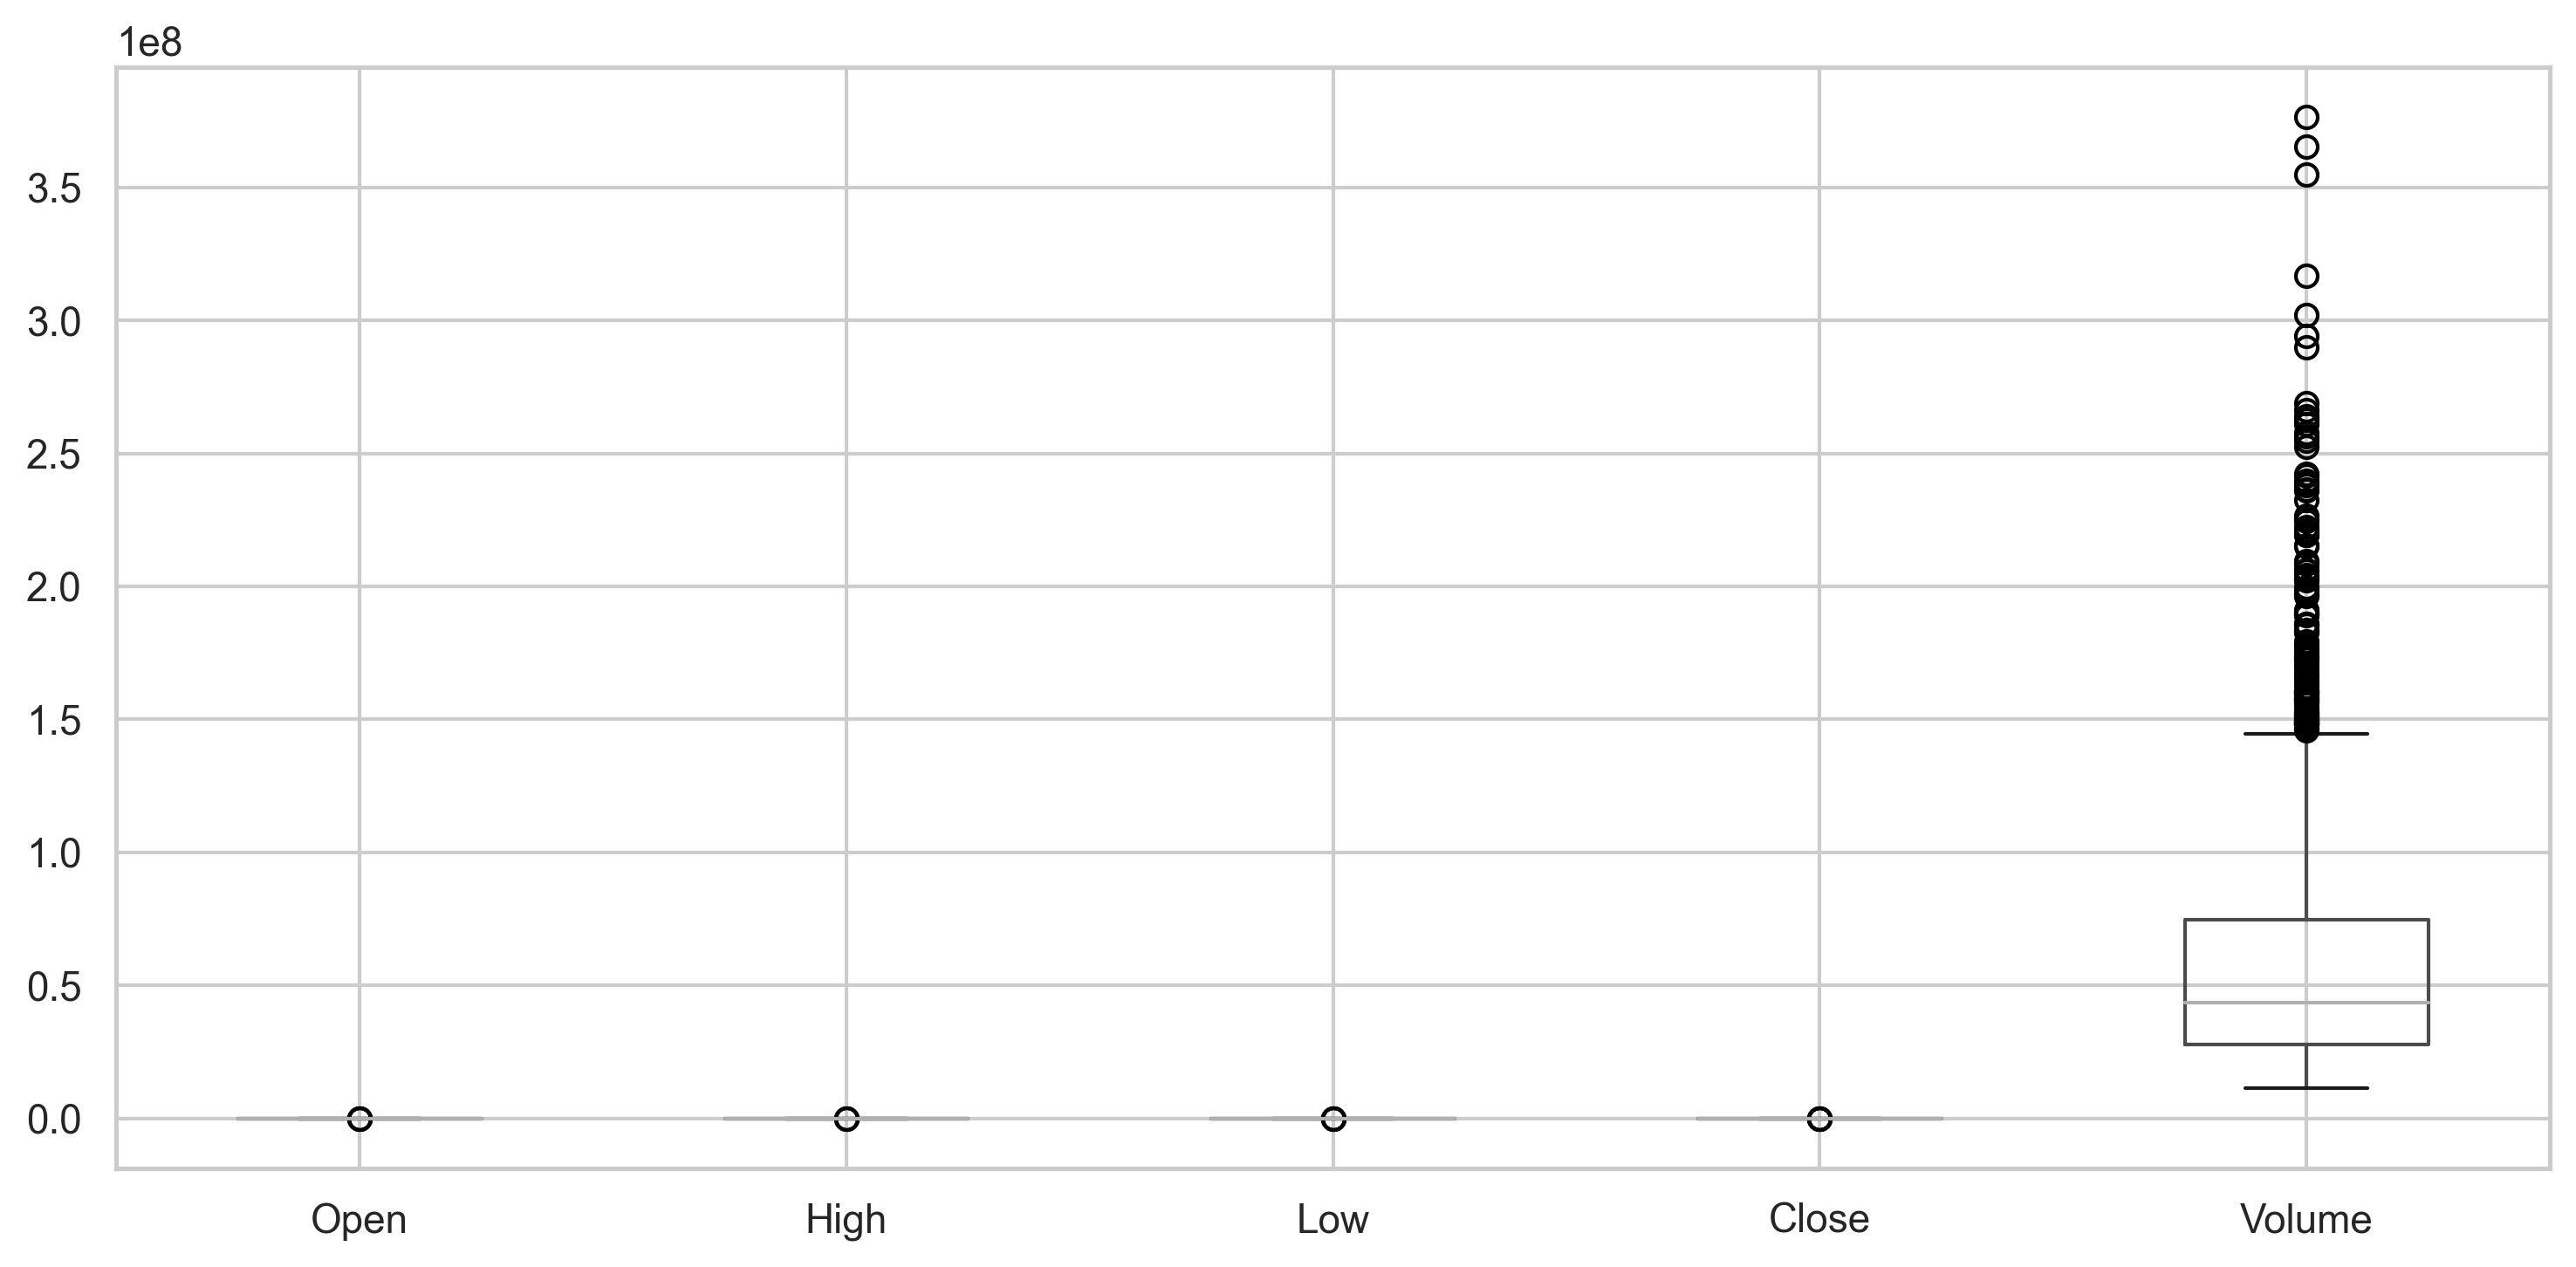

In [21]:
df.boxplot()
plt.tight_layout()

# Outlier detection function

In [22]:
def outlier_detection(data,colname):
    q1 = data[colname].quantile(0.25)
    q3 = data[colname].quantile(0.75)

    iqr = q3-q1

    upper = q3+(1.5*iqr)
    lower = q1-(1.5*iqr)

    return lower,upper

In [23]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

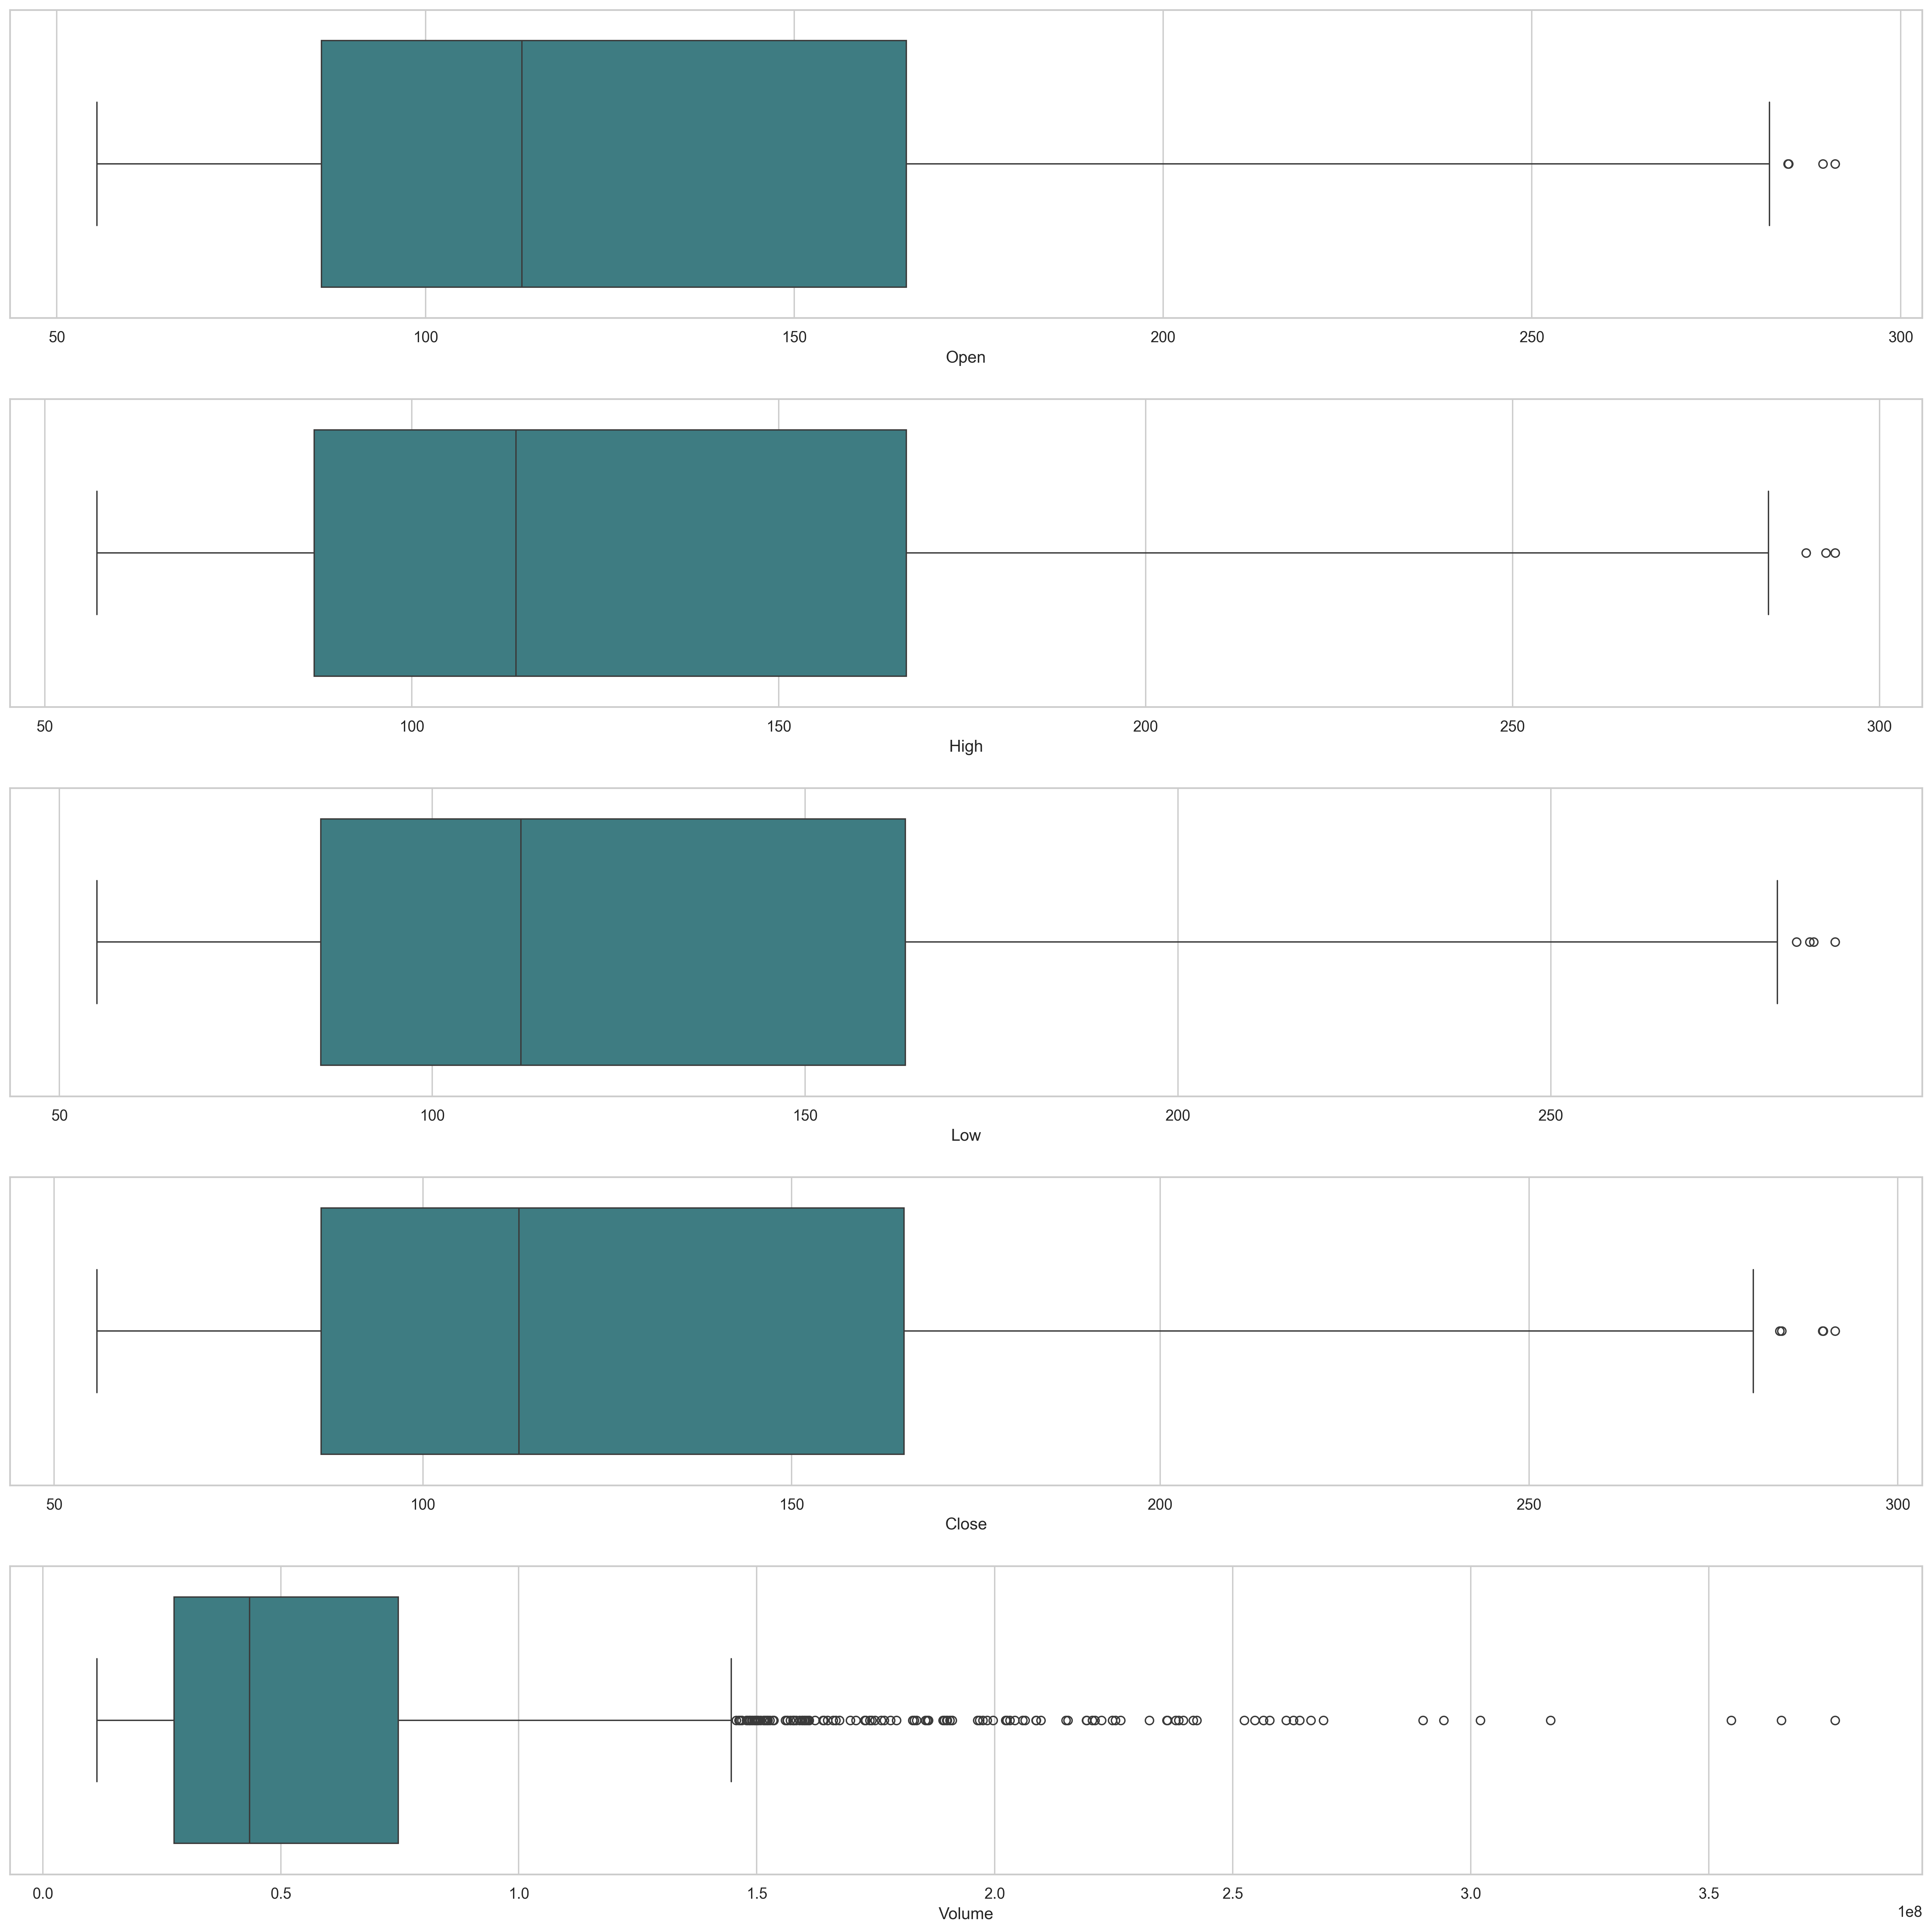

In [24]:
ot = df.copy()
fig, axes=plt.subplots(5,1,figsize=(20,20),sharex=False,sharey=False)
sns.boxplot(x='Open',data=ot,palette='crest',ax=axes[0])
sns.boxplot(x='High',data=ot,palette='crest',ax=axes[1])
sns.boxplot(x='Low',data=ot,palette='crest',ax=axes[2])
sns.boxplot(x='Close',data=ot,palette='crest',ax=axes[3])
sns.boxplot(x='Volume',data=ot,palette='crest',ax=axes[4])
plt.tight_layout(pad=2.0)

In [25]:
outlier_detection(df, "Open")

(-33.07785749999999, 284.1507185)

In [26]:
df.loc[df["Open"]>284.1507185, "Open"] = 284.1507185

In [27]:
outlier_detection(df, "High")

(-34.32035024999995, 288.44820374999995)

In [28]:
df.loc[df["High"]>288.44820374999995, "High"] = 288.44820374999995

In [29]:
outlier_detection(df, "Low")

(-32.49642575, 280.97784824999997)

In [30]:
df.loc[df["Low"]>280.97784824999997, "Low"] = 280.97784824999997

In [31]:
outlier_detection(df,"Close")

(-32.36214249999999, 283.8092895)

In [32]:
df.loc[df["Close"]>283.8092895, "Close"] = 283.8092895

In [33]:
outlier_detection(df, "Volume")

(-43101325.0, 145397275.0)

In [34]:
df.loc[df["Volume"]>145397275.0, "Volume"] = 145397275.0

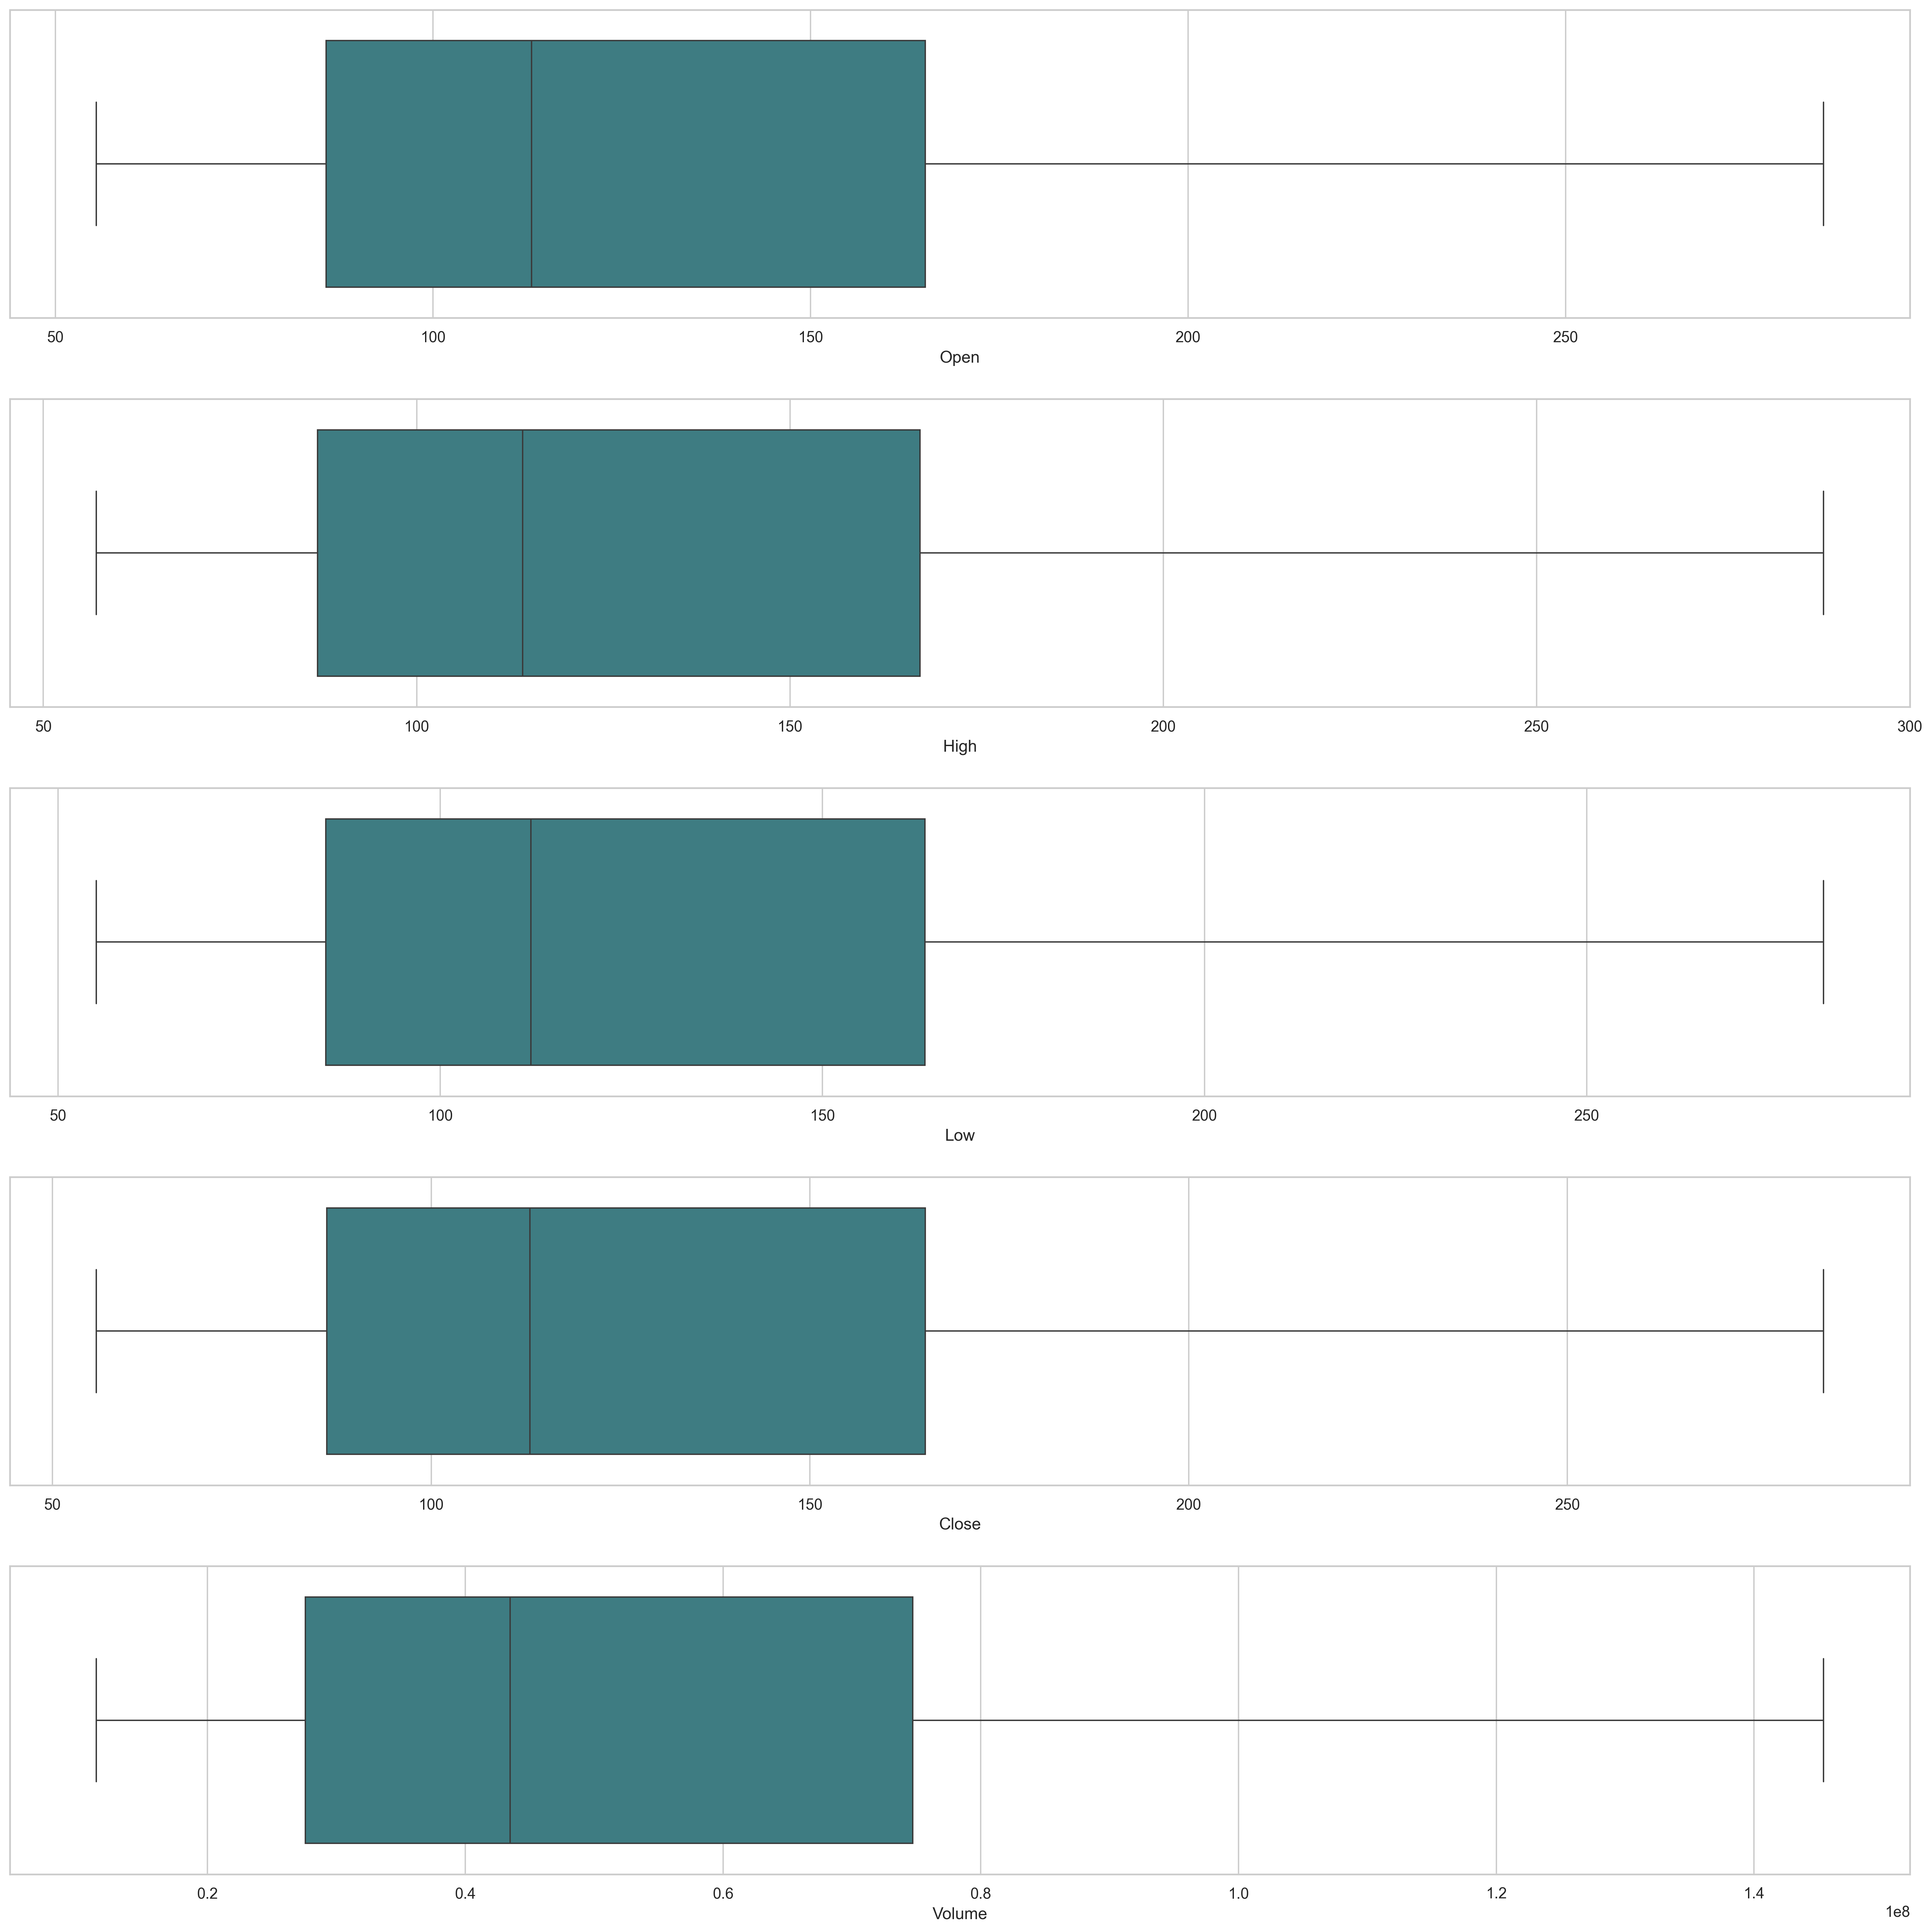

In [35]:
ot = df.copy()
fig, axes=plt.subplots(5,1,figsize=(20,20),sharex=False,sharey=False)
sns.boxplot(x='Open',data=ot,palette='crest',ax=axes[0])
sns.boxplot(x='High',data=ot,palette='crest',ax=axes[1])
sns.boxplot(x='Low',data=ot,palette='crest',ax=axes[2])
sns.boxplot(x='Close',data=ot,palette='crest',ax=axes[3])
sns.boxplot(x='Volume',data=ot,palette='crest',ax=axes[4])
plt.tight_layout(pad=2.0)

# Scatter Plot and Correlation

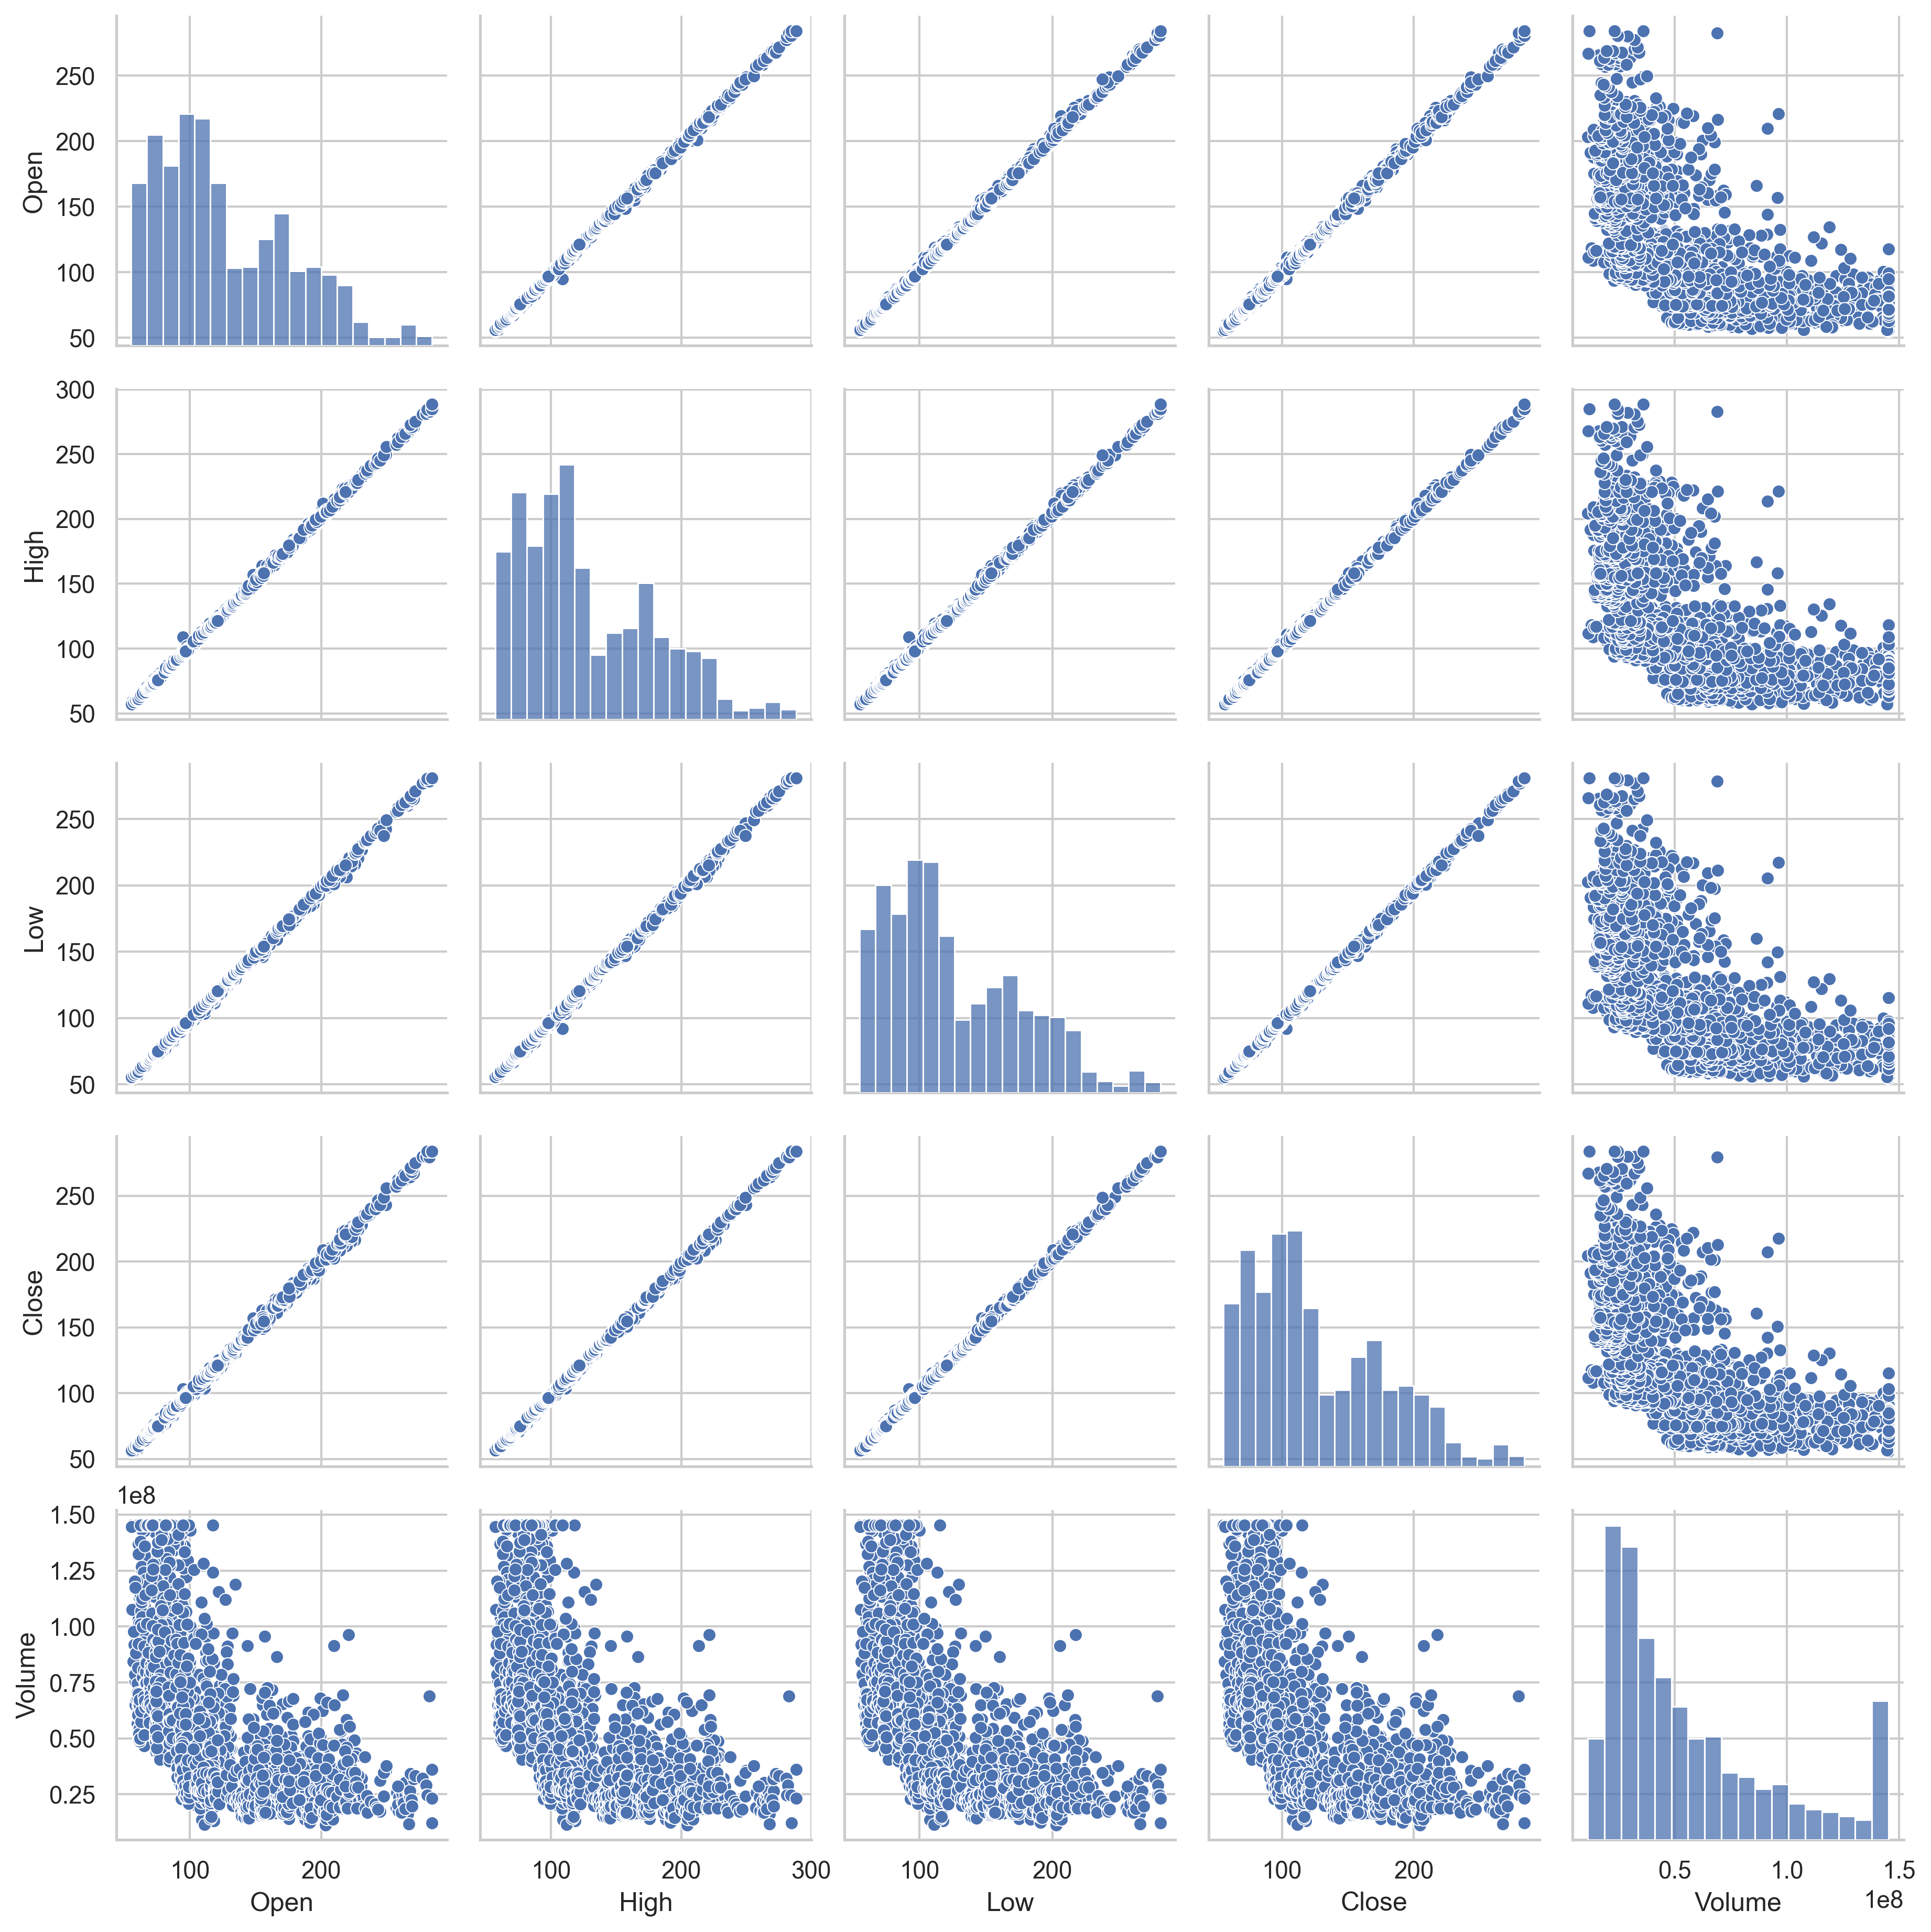

In [36]:
#univariate, bivariate, multivariate analysis
sns.pairplot(df)

**Correlation coefficient**

In [37]:
df.corr(numeric_only=True)

,Open,High,Low,Close,Volume
Open,1.000000,0.999782,0.999719,0.999498,-0.623331
High,0.999782,1.000000,0.999656,0.999747,-0.620143
Low,0.999719,0.999656,1.000000,0.999771,-0.628784
Close,0.999498,0.999747,0.999771,1.000000,-0.624962
Volume,-0.623331,-0.620143,-0.628784,-0.624962,1.000000


<Axes: >

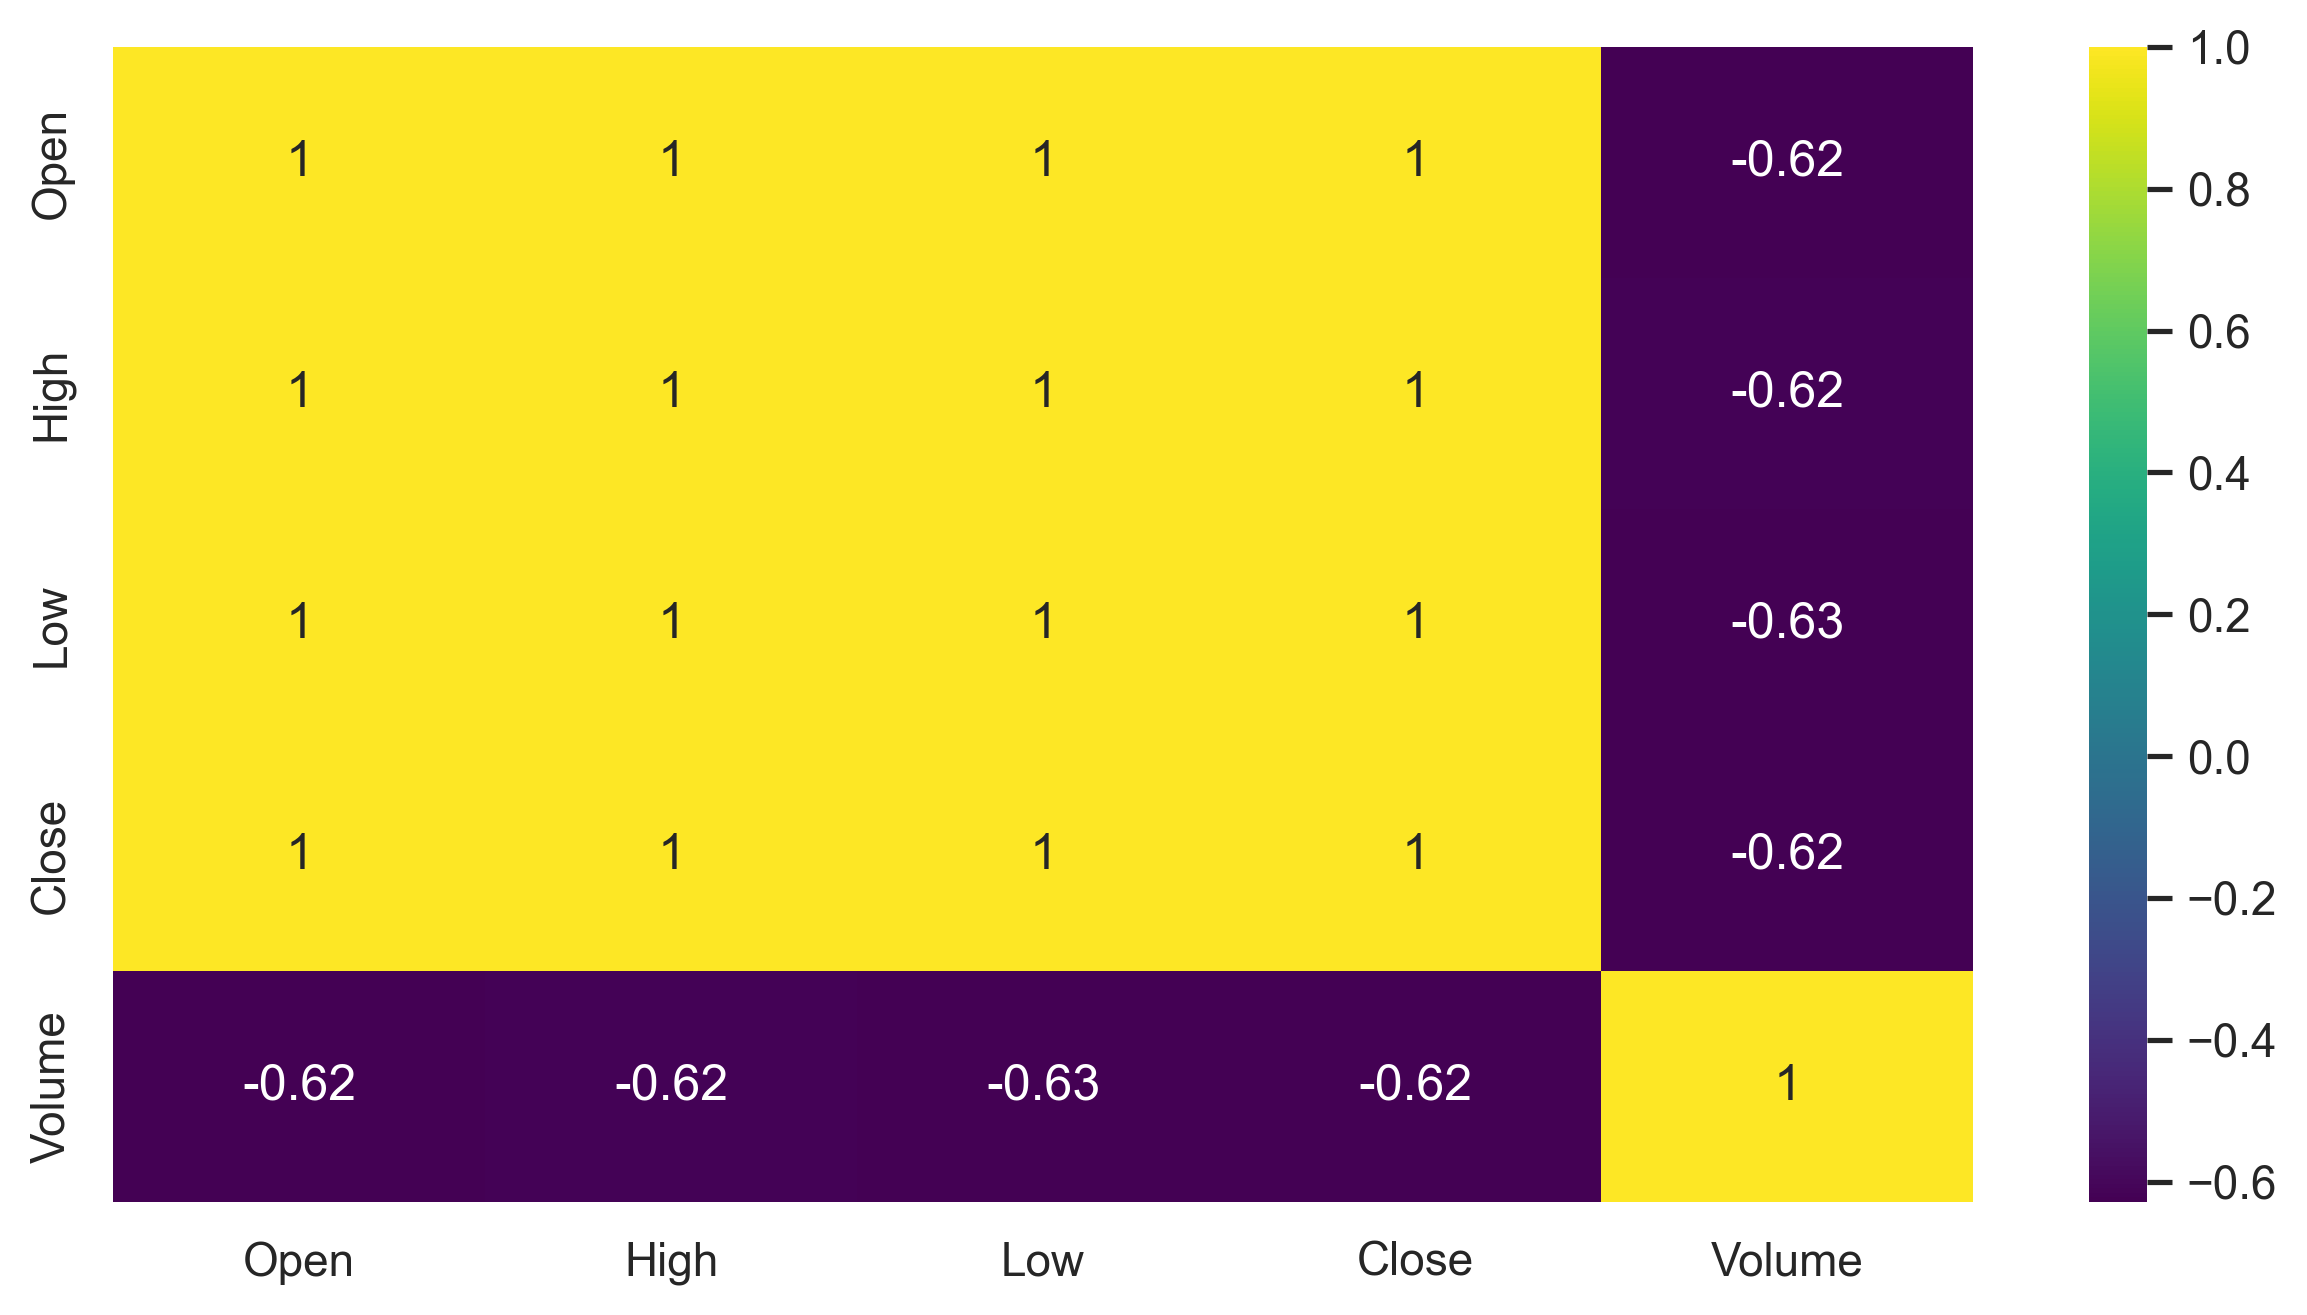

In [38]:
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap="viridis")

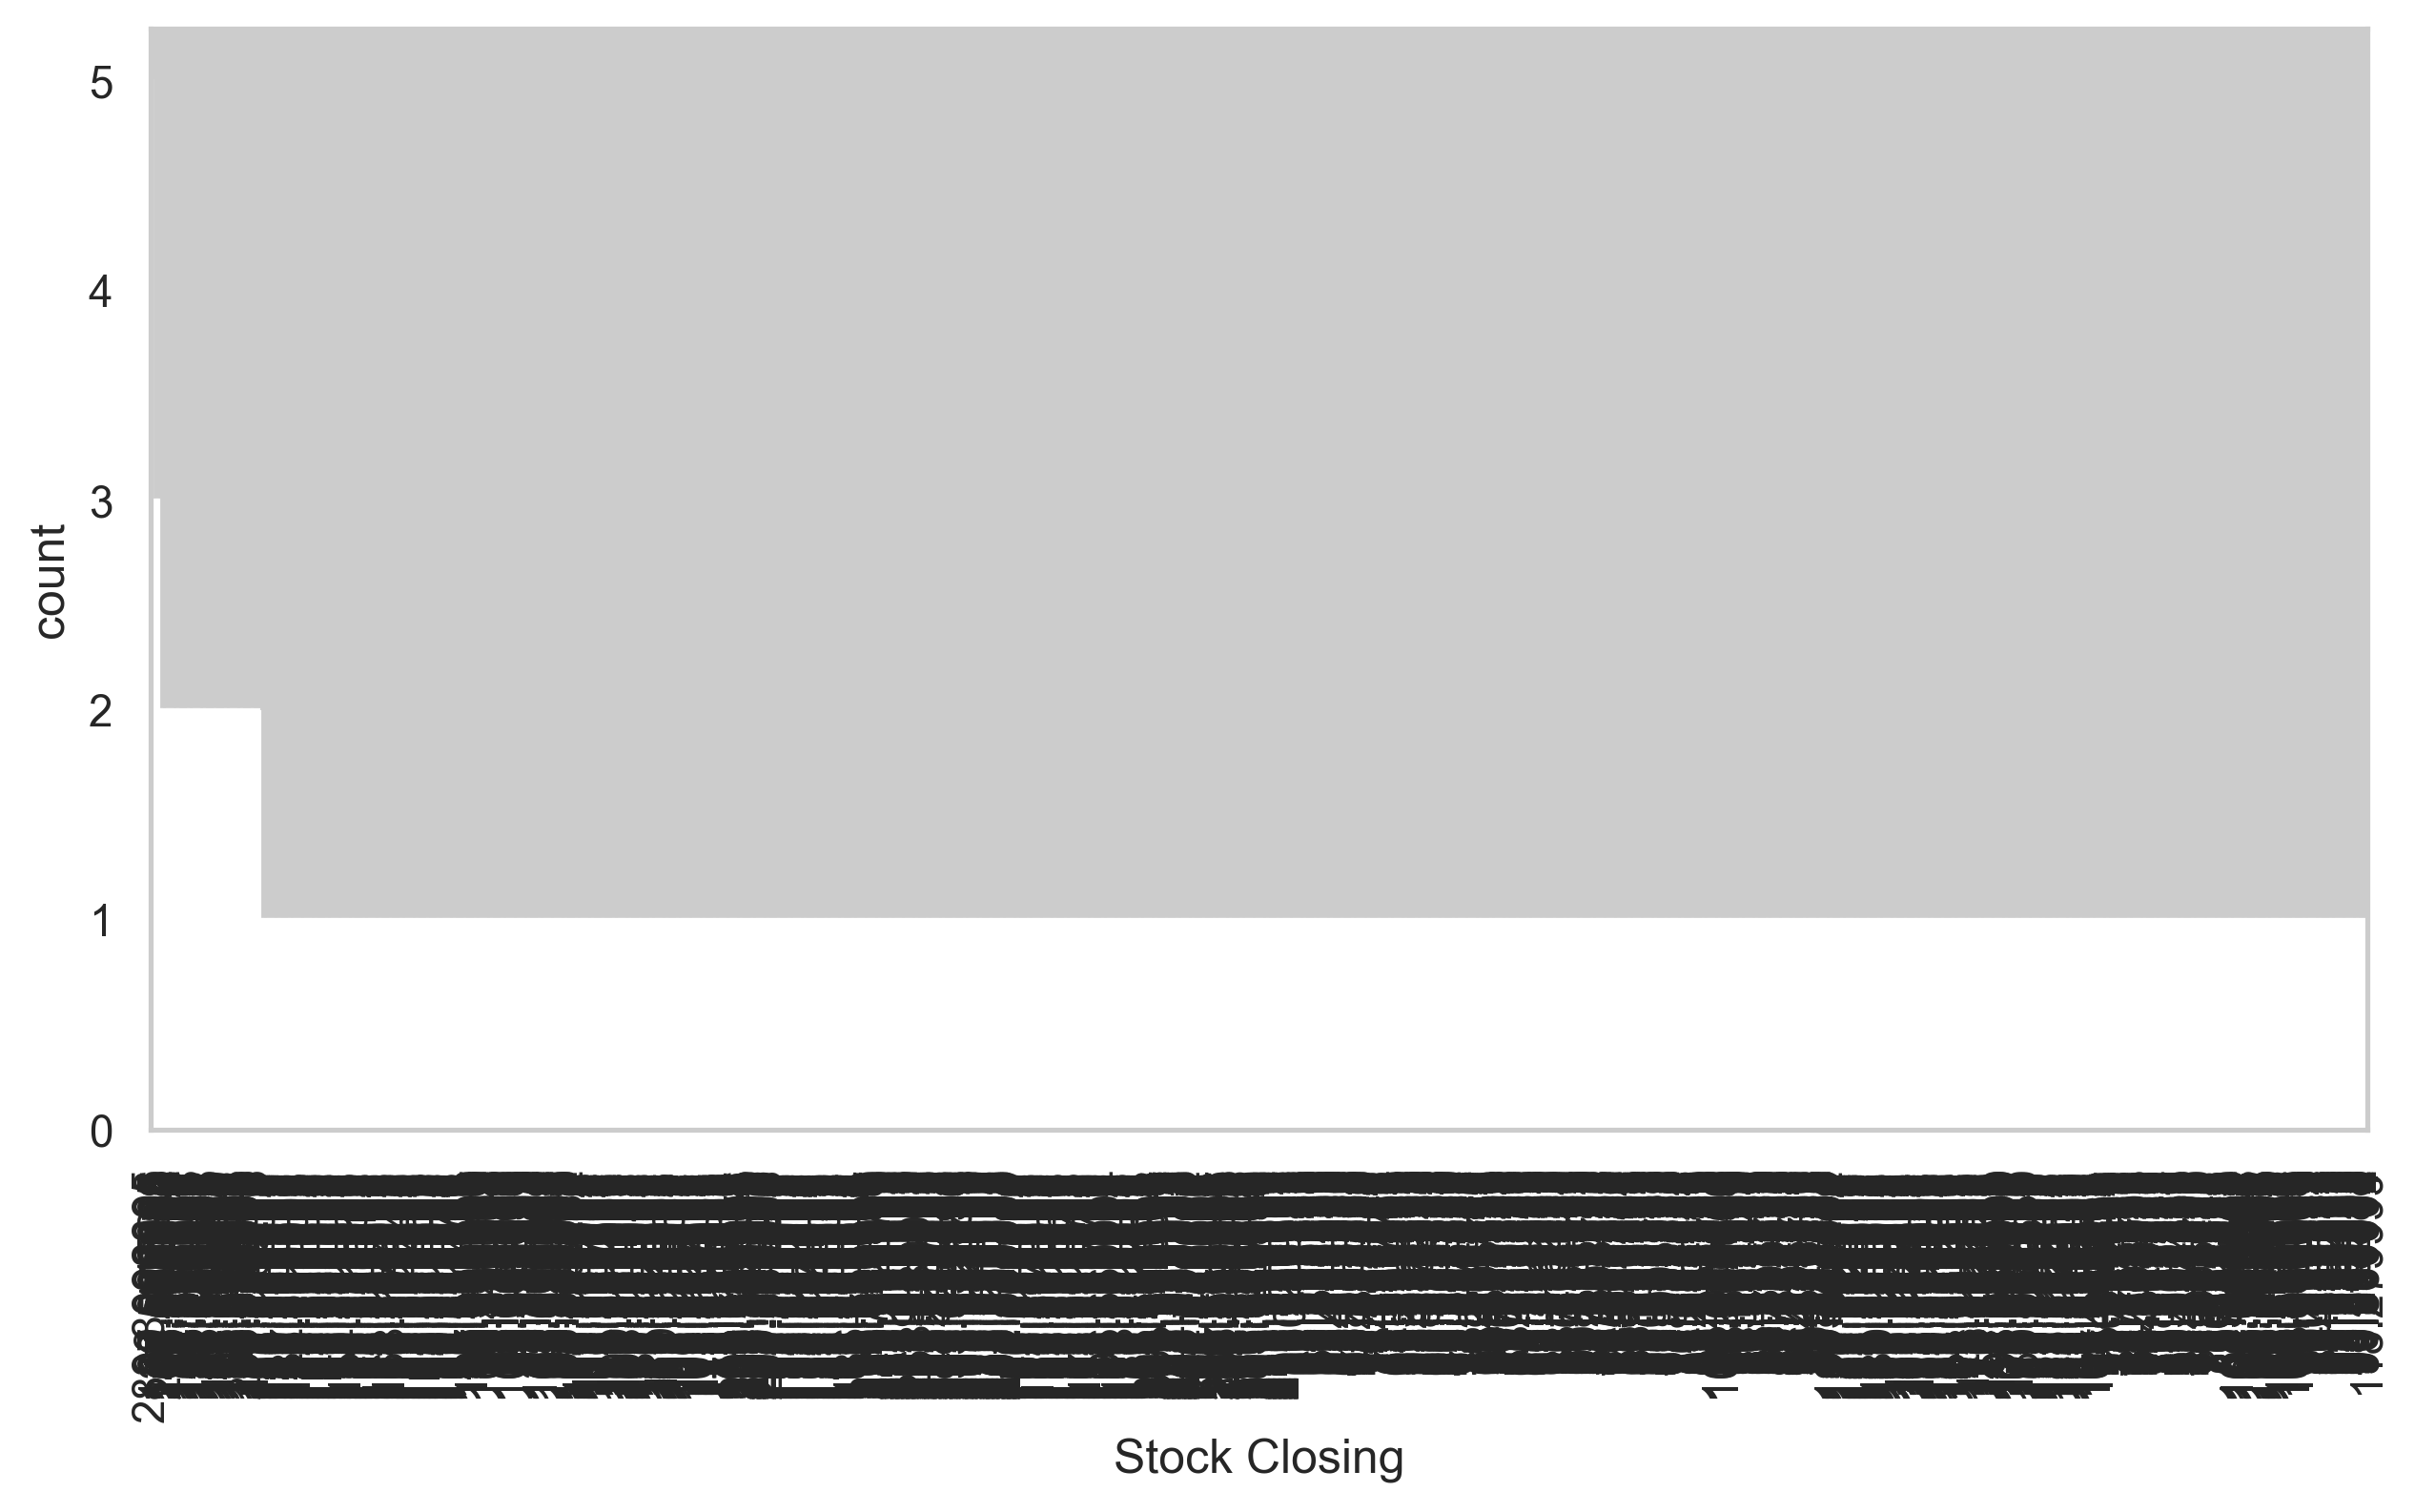

In [39]:
## Visulaization
## Conclusion - it is on imbalanced dataset
df.Close.value_counts().plot(kind="bar")
plt.xlabel("Stock Closing")
plt.ylabel("count")
plt.show()

<function matplotlib.pyplot.tight_layout(*, pad=1.08, h_pad=None, w_pad=None, rect=None)>

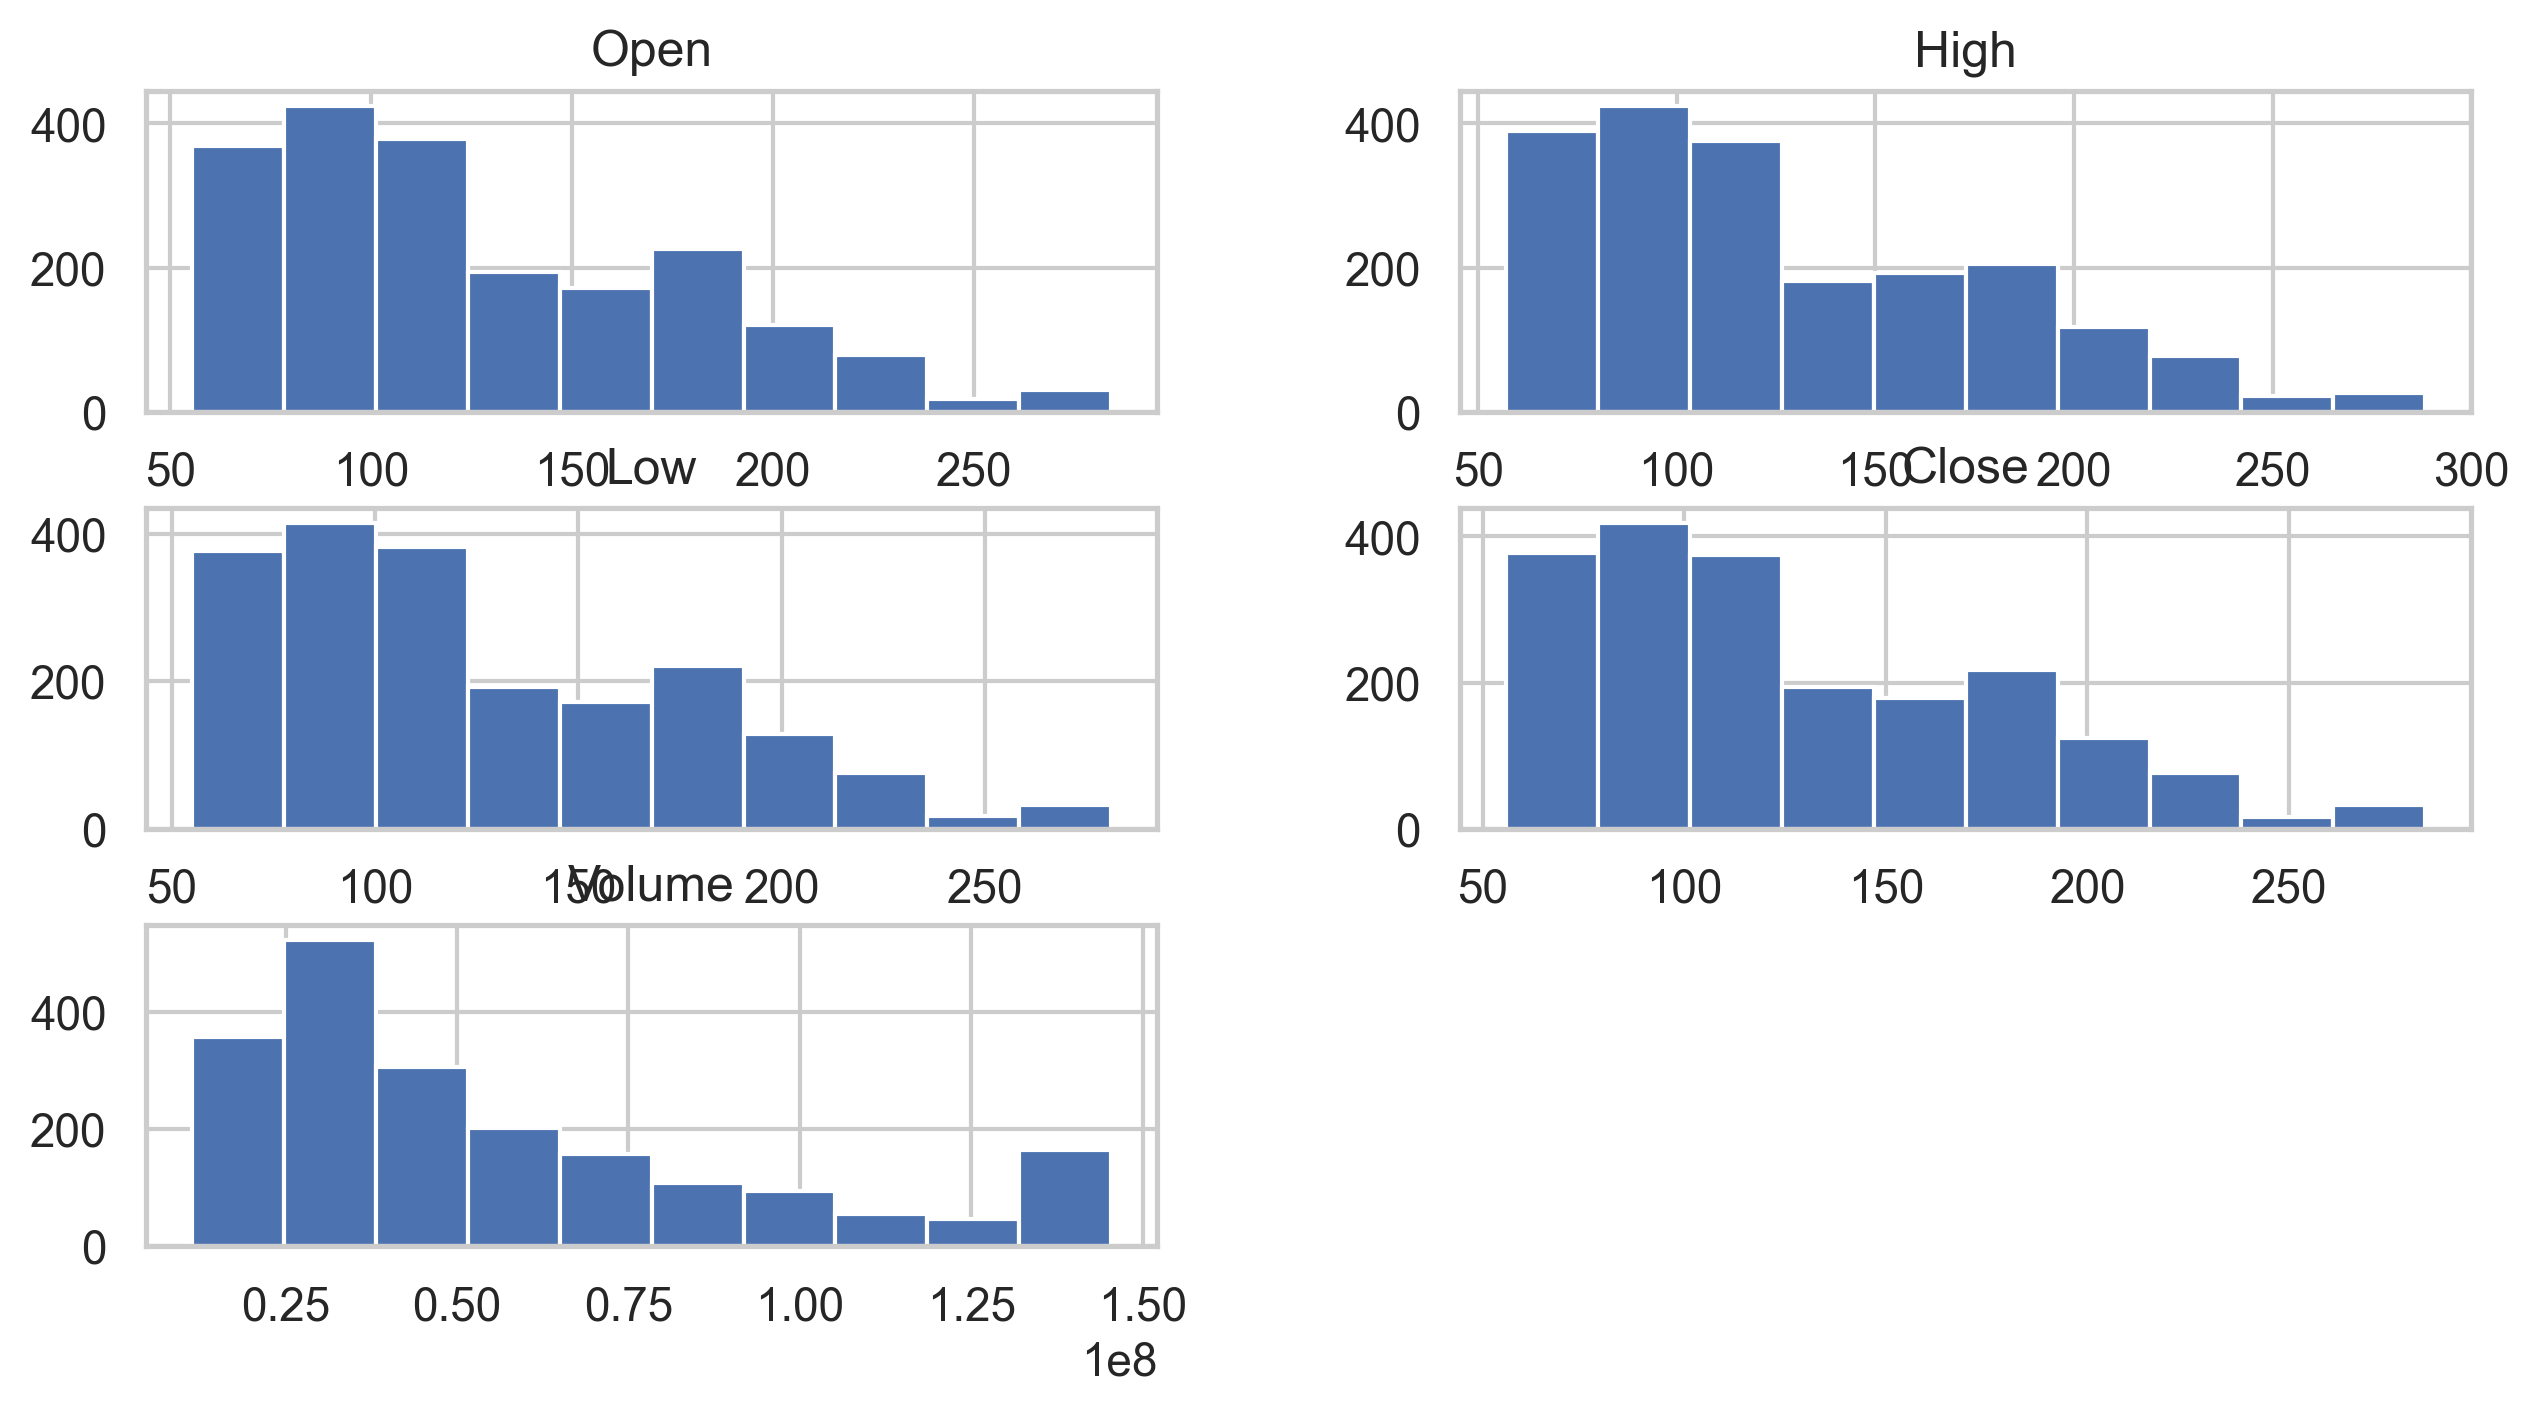

In [40]:
df.hist()
plt.tight_layout

<Axes: xlabel='Date'>

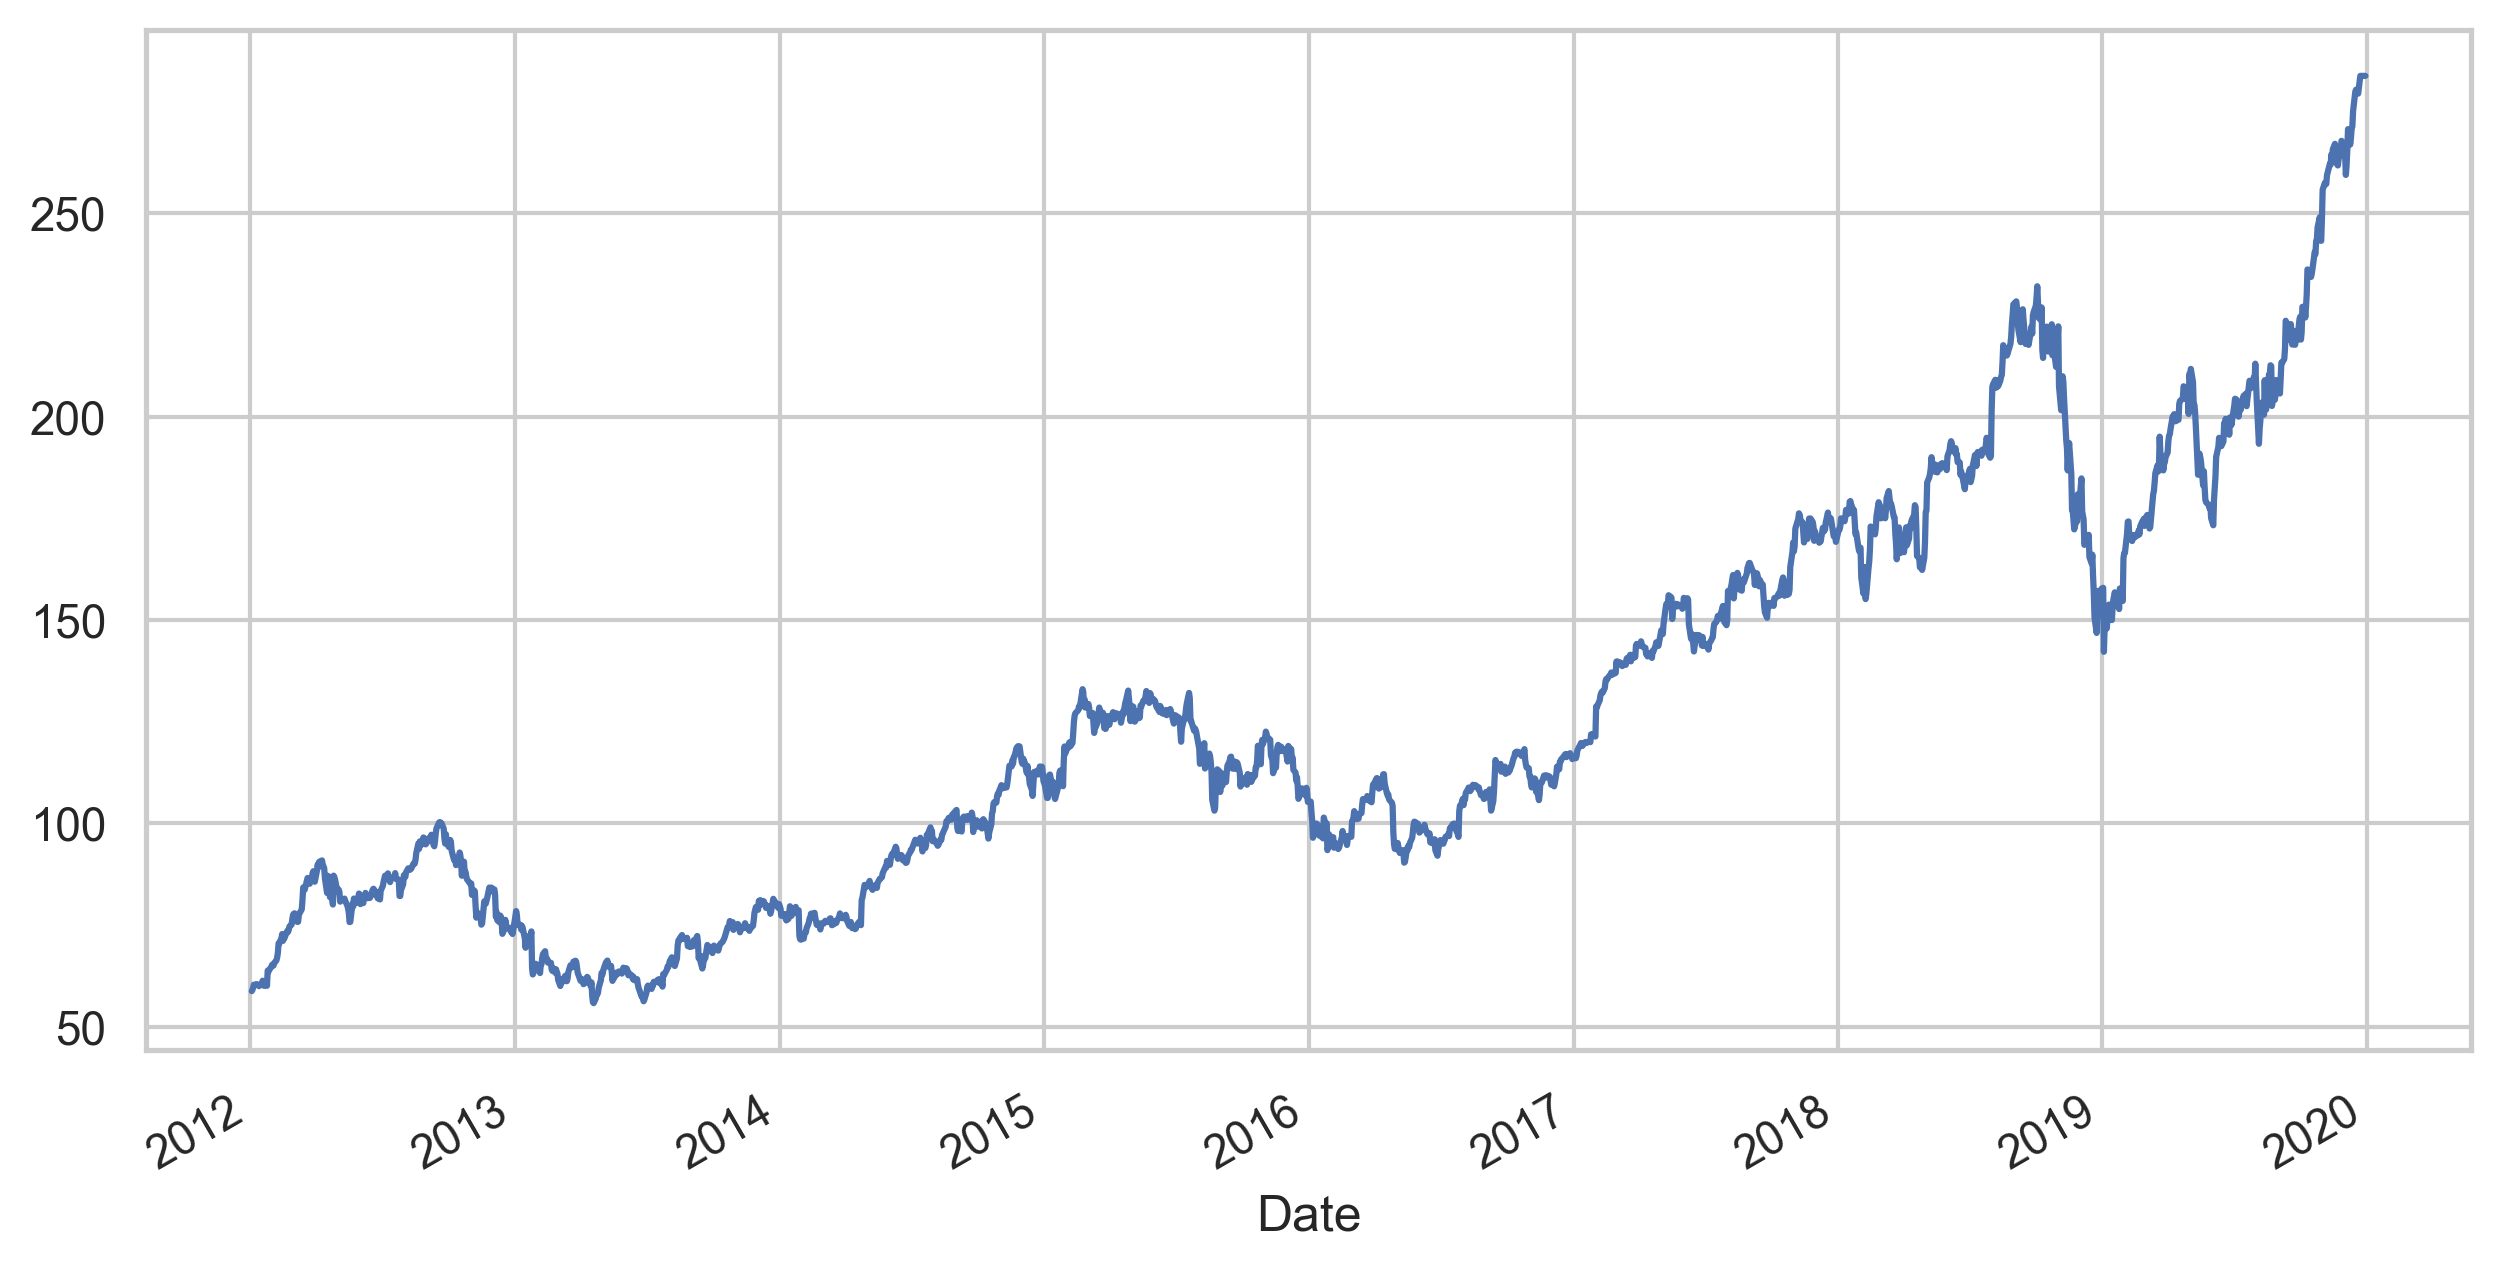

In [41]:
df["Close"].plot()

<Axes: xlabel='Open', ylabel='Close'>

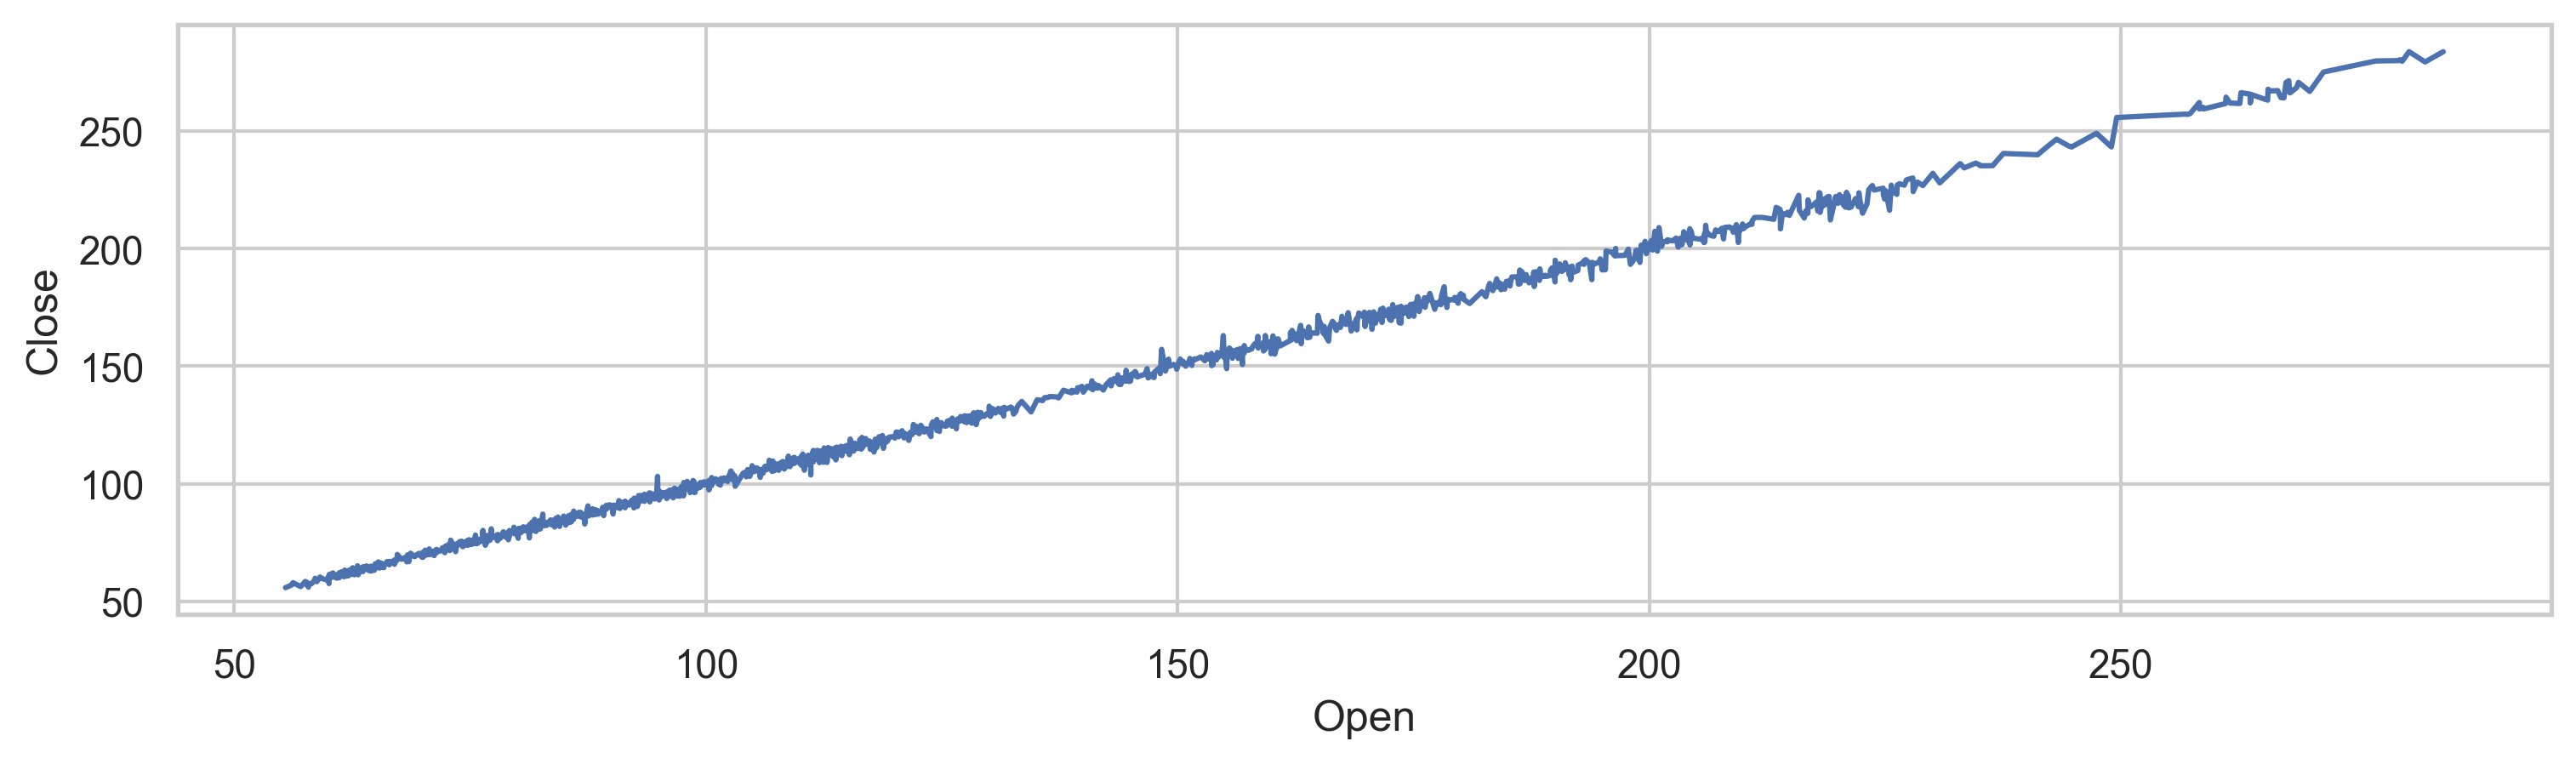

In [42]:
plt.figure(figsize=(12,3))
sns.lineplot(x="Open",y="Close",data=df)

<Axes: title={'center': 'Stock Price with Moving Averages'}, xlabel='Date'>

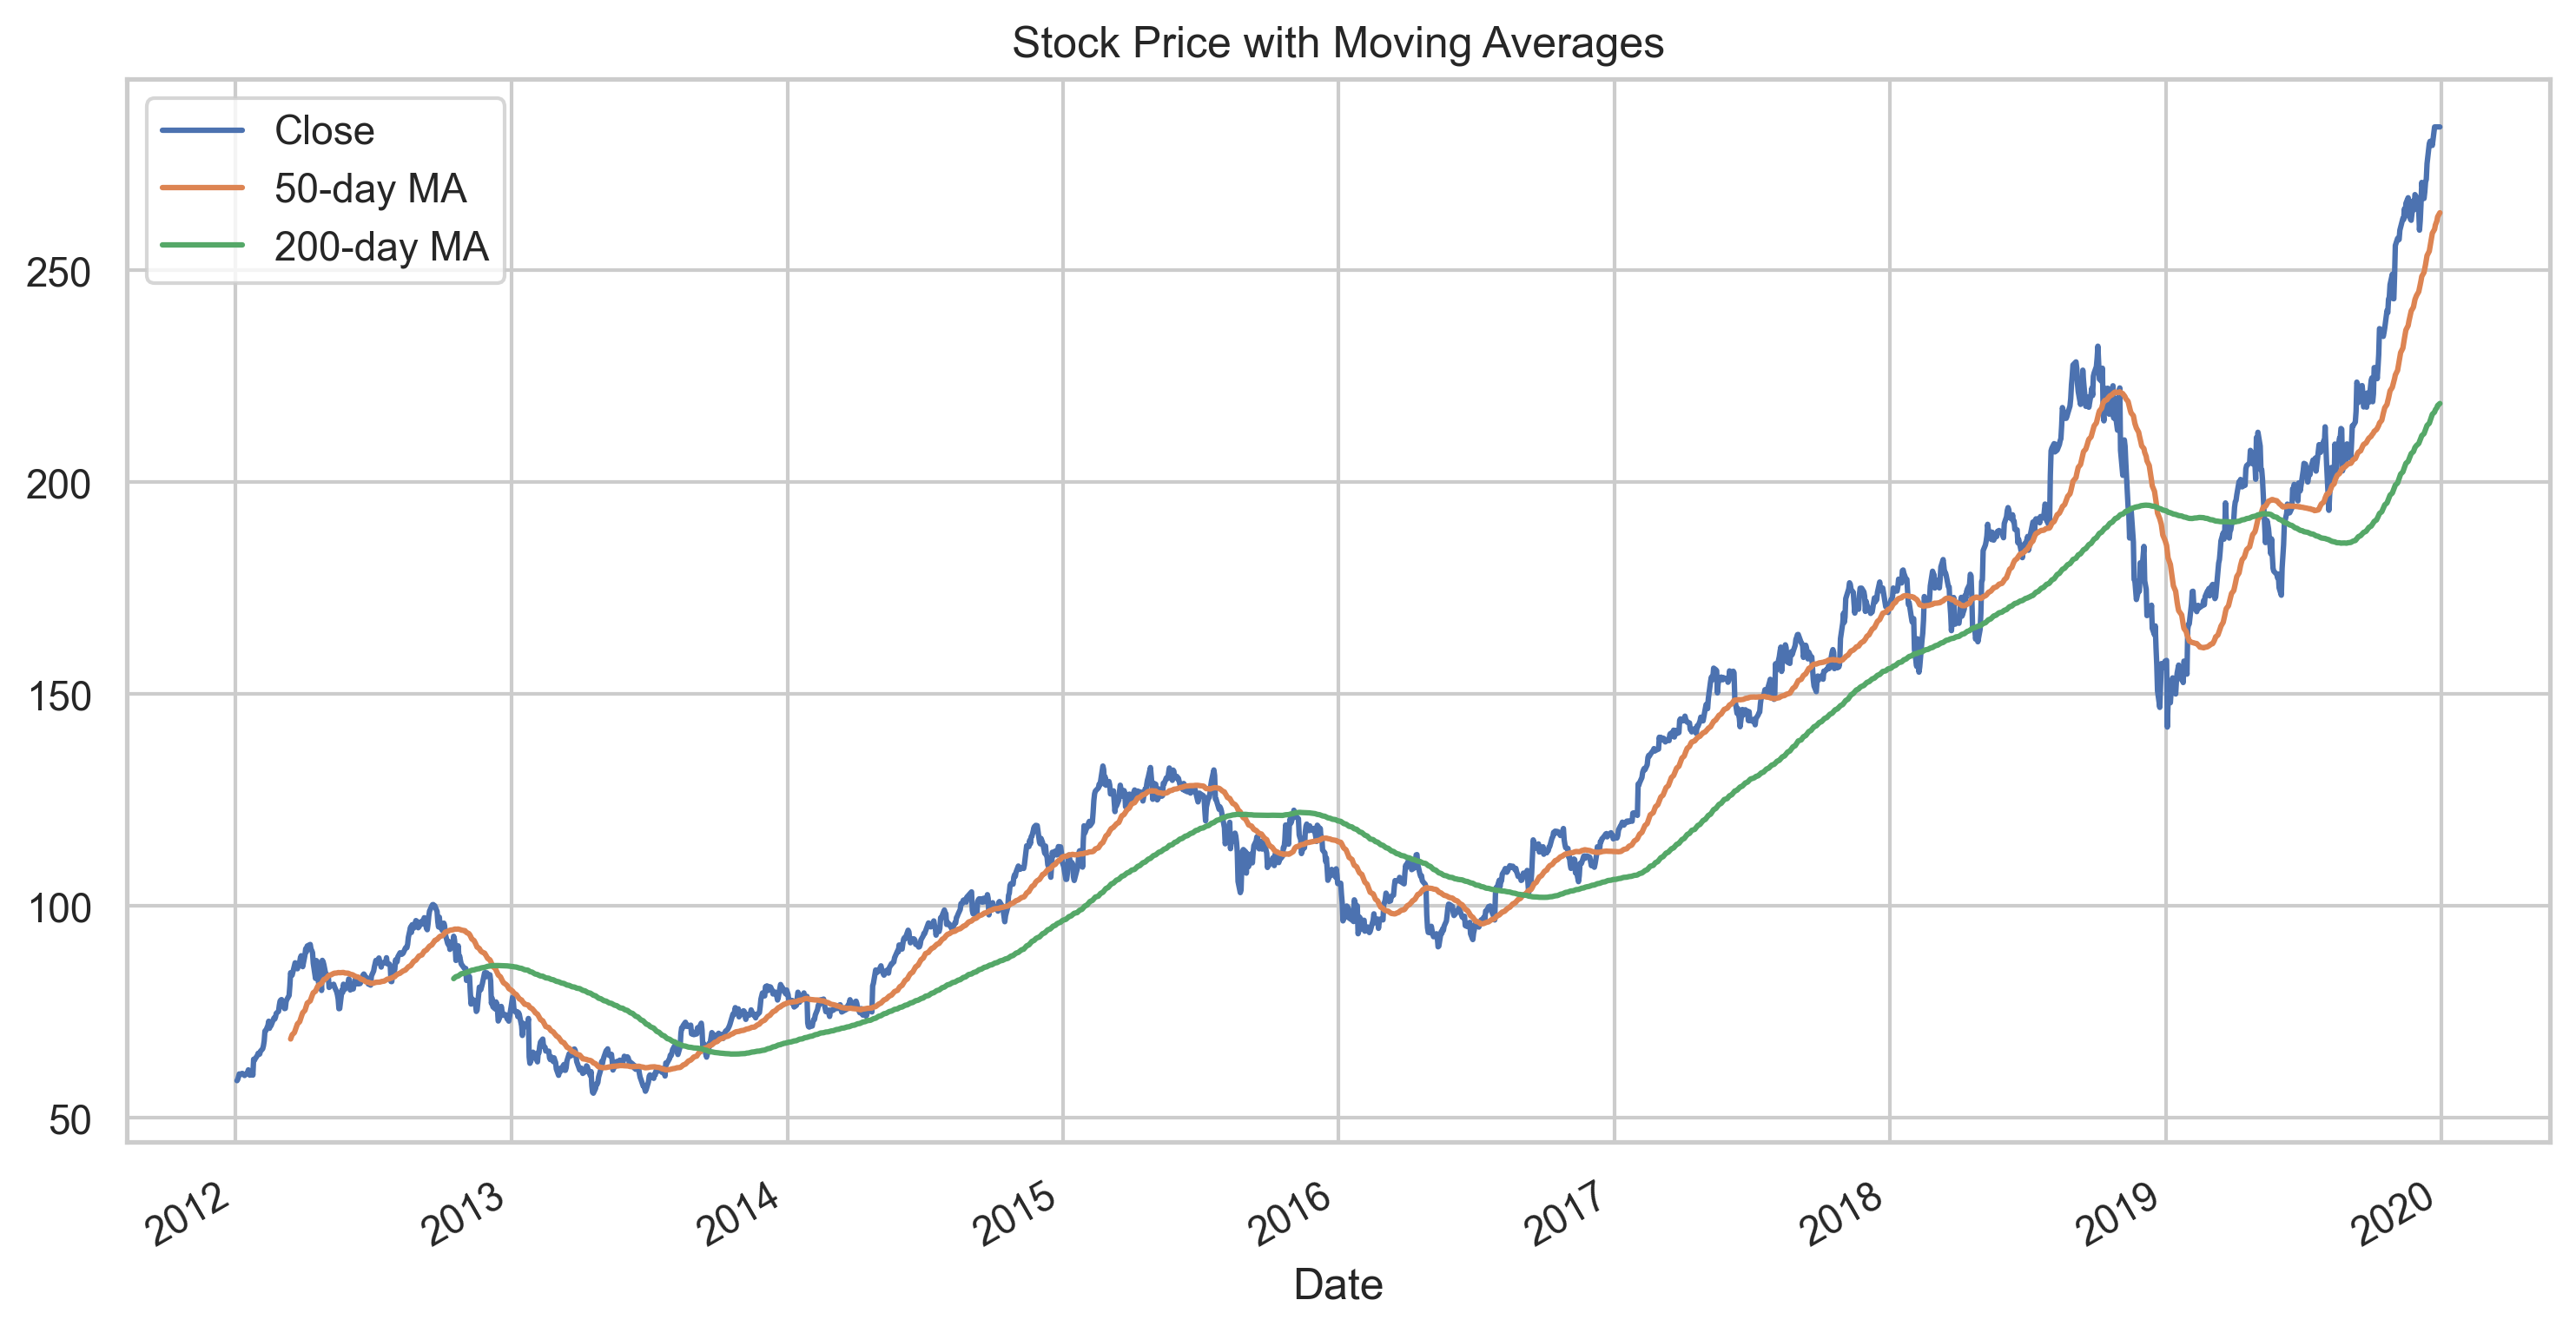

In [43]:
#Compute Moving Averages (Short-term & Long-term Trends)
df['50-day MA'] = df['Close'].rolling(window=50).mean()
df['200-day MA'] = df['Close'].rolling(window=200).mean()
df[['Close', '50-day MA', '200-day MA']].plot(figsize=(12,6), title="Stock Price with Moving Averages")

**Stationarity & Time Series Analysis**

In [44]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [45]:
def adf_test(series, title=''):
    """
    Perform the Augmented Dickey-Fuller test and print the results.
    """
    print(f'\nADF Test: {title}')
    result = adfuller(series.dropna(), autolag='AIC')
    labels = ['ADF Statistic', 'p-value', '# Lags Used', 'Number of Observations Used']
    for label, value in zip(labels, result):
        print(f"{label}: {value}")
    if result[1] <= 0.05:
        print("=> The series is likely stationary.\n")
    else:
        print("=> The series is likely non-stationary.\n")

In [46]:
# Test stationarity on the original 'Close' series
adf_test(df['Close'], 'Stock Close Price')


ADF Test: Stock Close Price
ADF Statistic: 0.984317559130625
p-value: 0.9940976935123645
# Lags Used: 9
Number of Observations Used: 2001
=> The series is likely non-stationary.



In [47]:
len(df)

2011

In [48]:
df.isnull().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
50-day MA      49
200-day MA    199
dtype: int64

In [49]:
df['Close_diff'] = df['Close'].diff()
adf_test(df['Close_diff'], 'Differenced Stock Close Price')


ADF Test: Differenced Stock Close Price
ADF Statistic: -13.786088612366864
p-value: 9.106620961204917e-26
# Lags Used: 8
Number of Observations Used: 2001
=> The series is likely stationary.



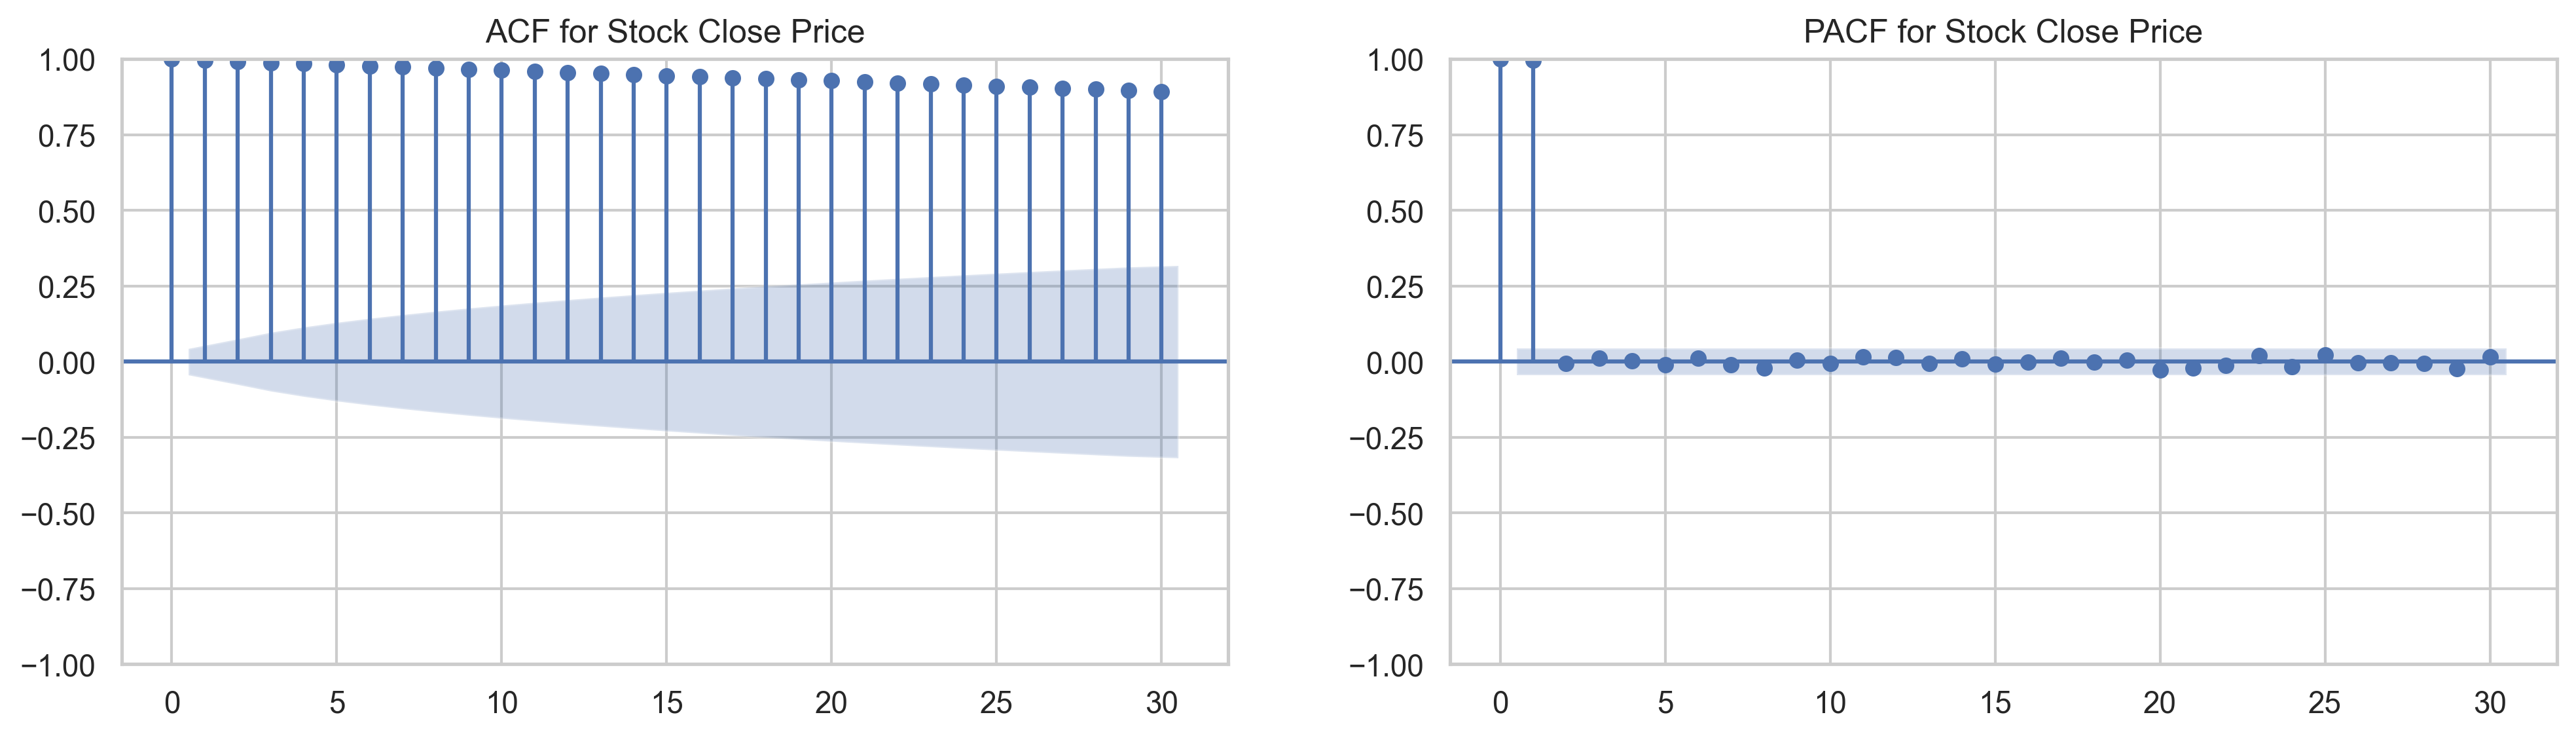

In [50]:
# Plot ACF and PACF for the original series
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['Close'], ax=axes[0], lags=30)
axes[0].set_title('ACF for Stock Close Price')
plot_pacf(df['Close'], ax=axes[1], lags=30)
axes[1].set_title('PACF for Stock Close Price')
plt.show()

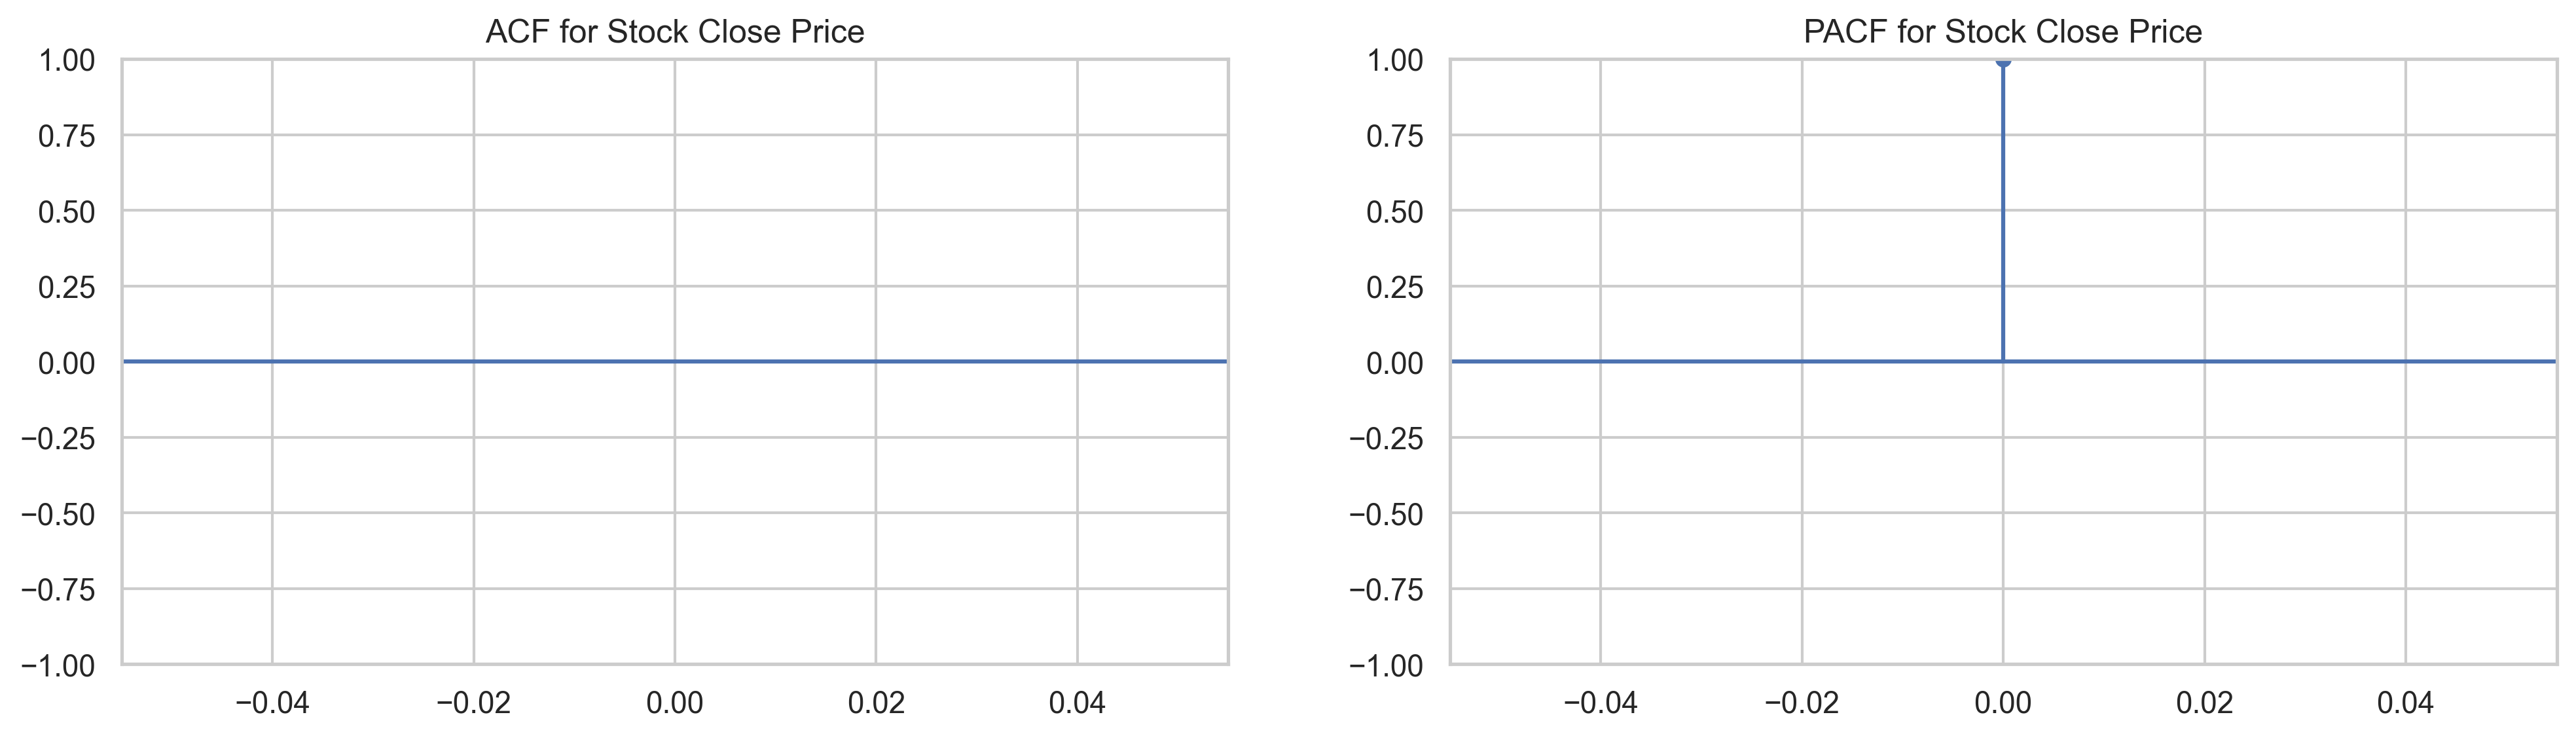

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['Close_diff'], ax=axes[0], lags=30)
axes[0].set_title('ACF for Stock Close Price')
plot_pacf(df['Close_diff'], ax=axes[1], lags=30)
axes[1].set_title('PACF for Stock Close Price')
plt.show()

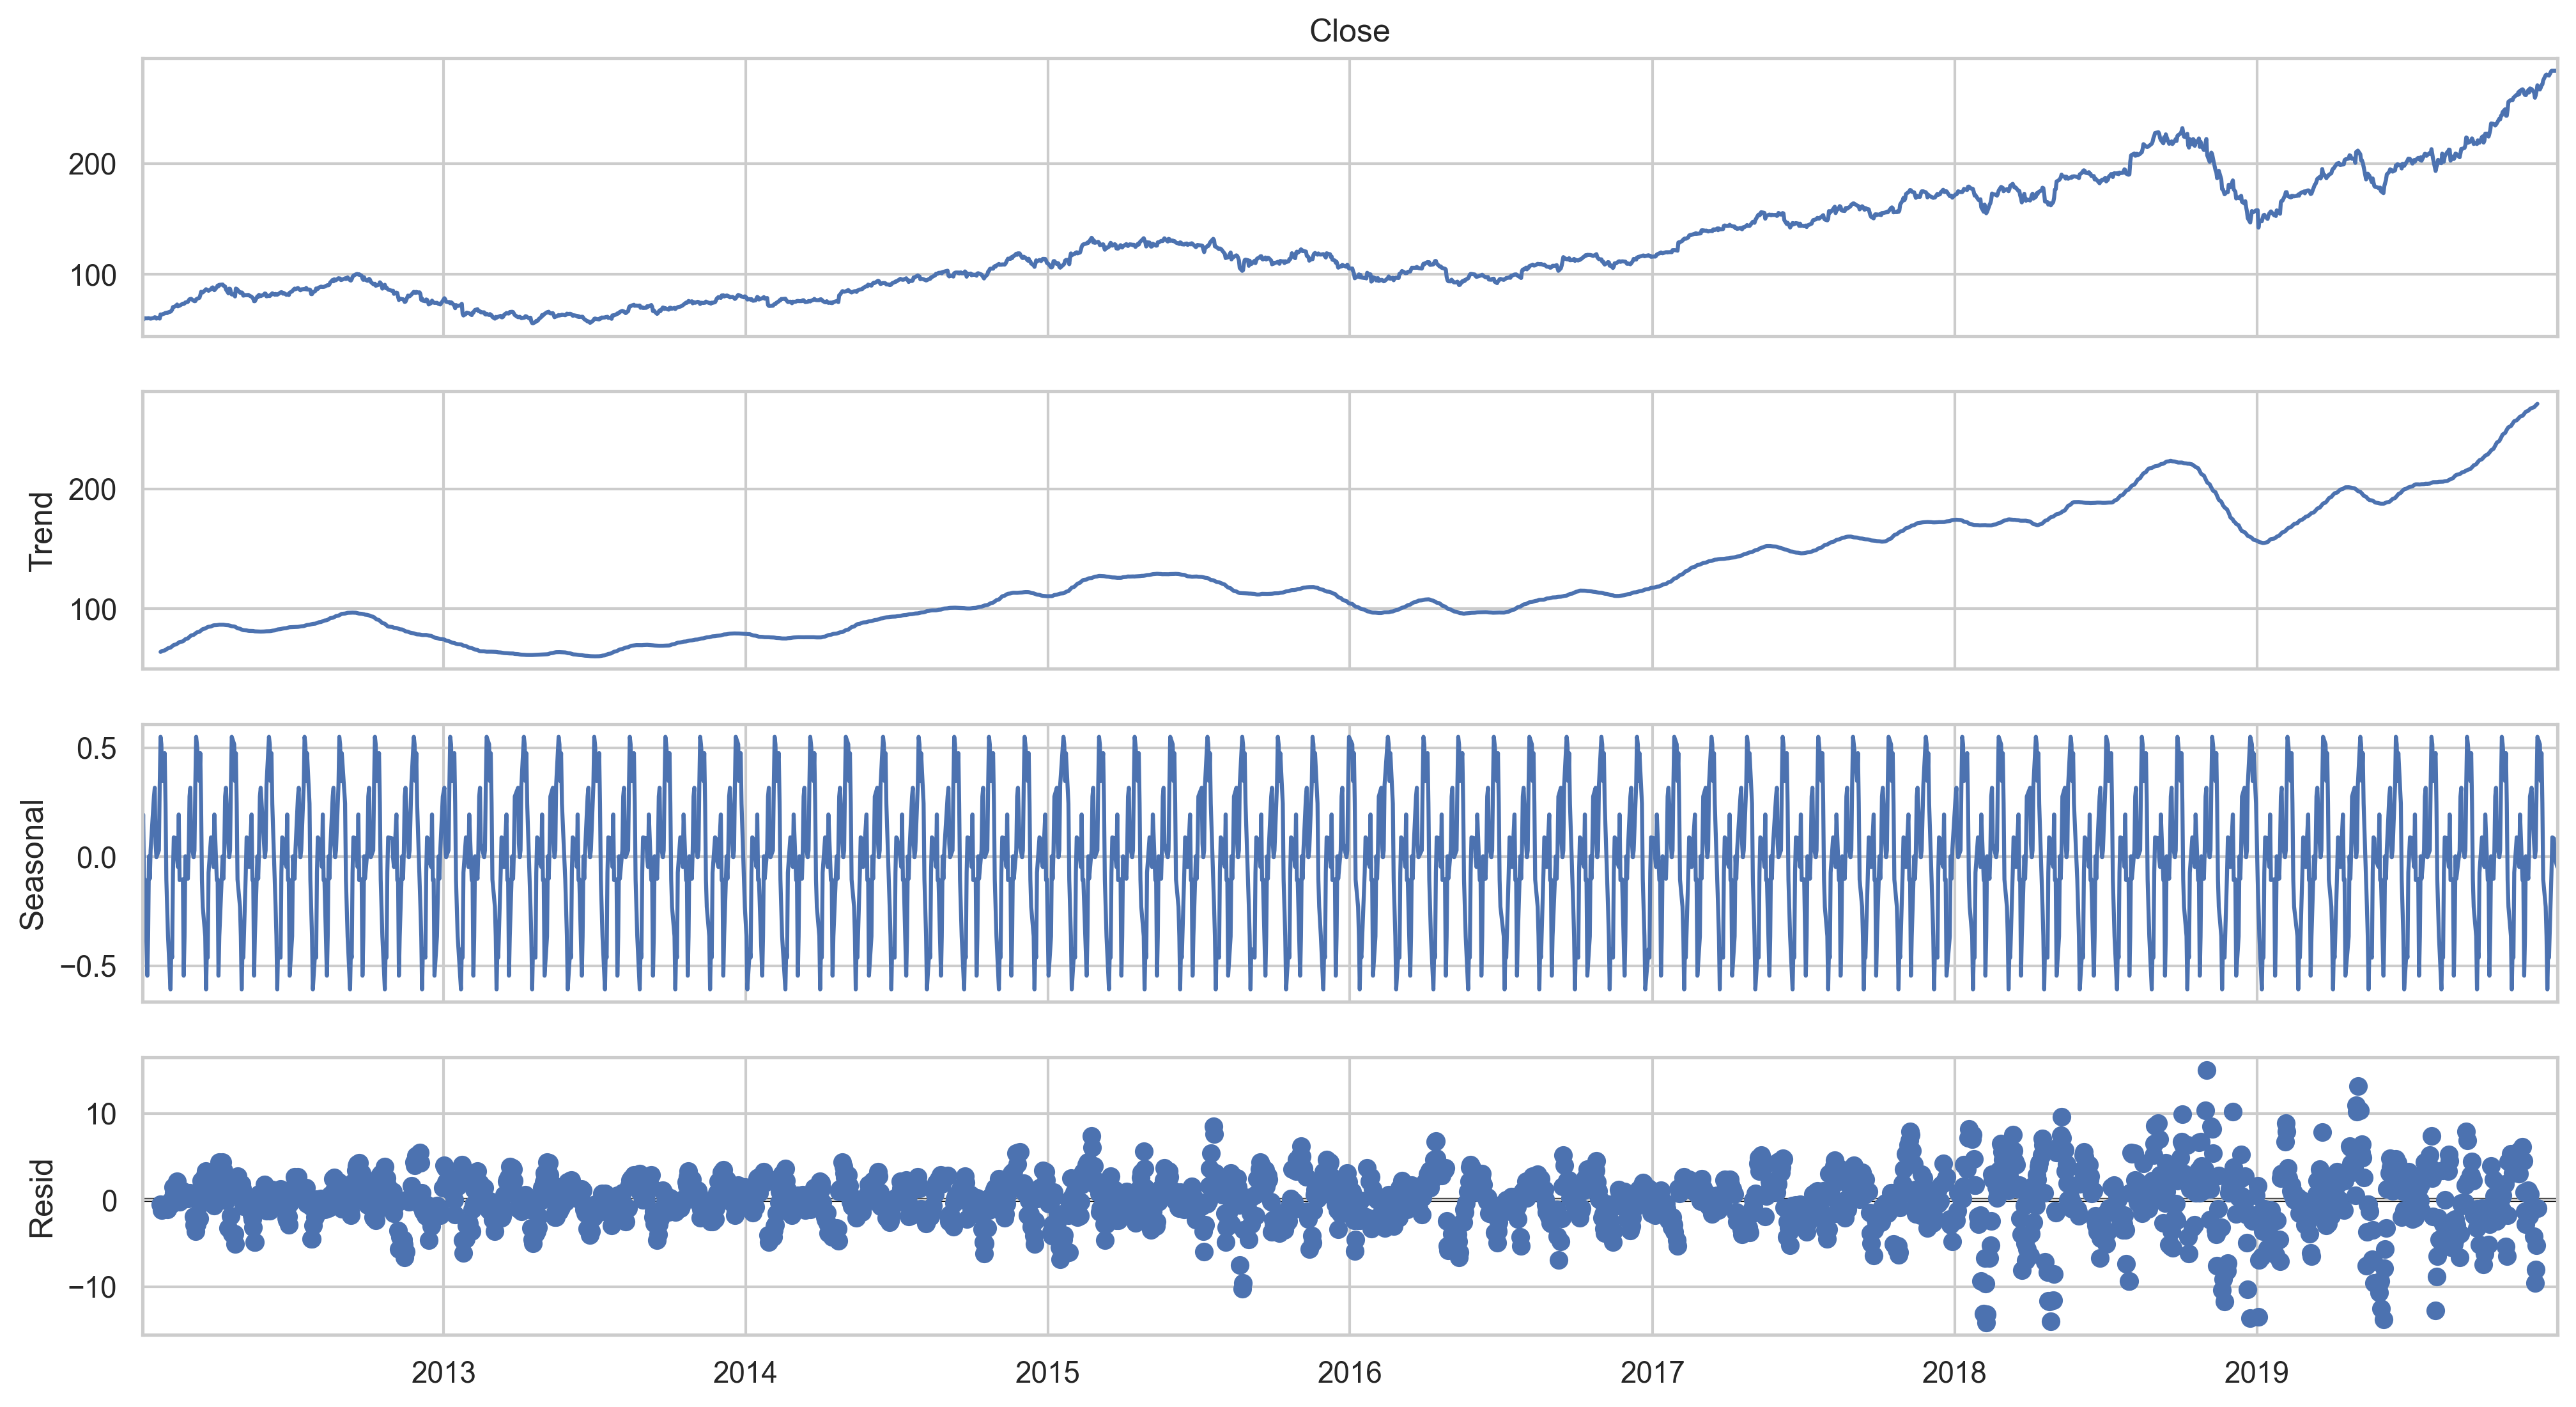

In [52]:
decomposition = seasonal_decompose(df['Close'], model='additive', period=30)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.show()

In [53]:
#Feature Engineering
# Create lag features (e.g., 1-day and 7-day lags)
df['lag_1'] = df['Close'].shift(1)
df['lag_7'] = df['Close'].shift(7)

In [54]:
# Create rolling statistics (7-day rolling mean and standard deviation)
df['rolling_mean_7'] = df['Close'].rolling(window=7).mean()
df['rolling_std_7'] = df['Close'].rolling(window=7).std()

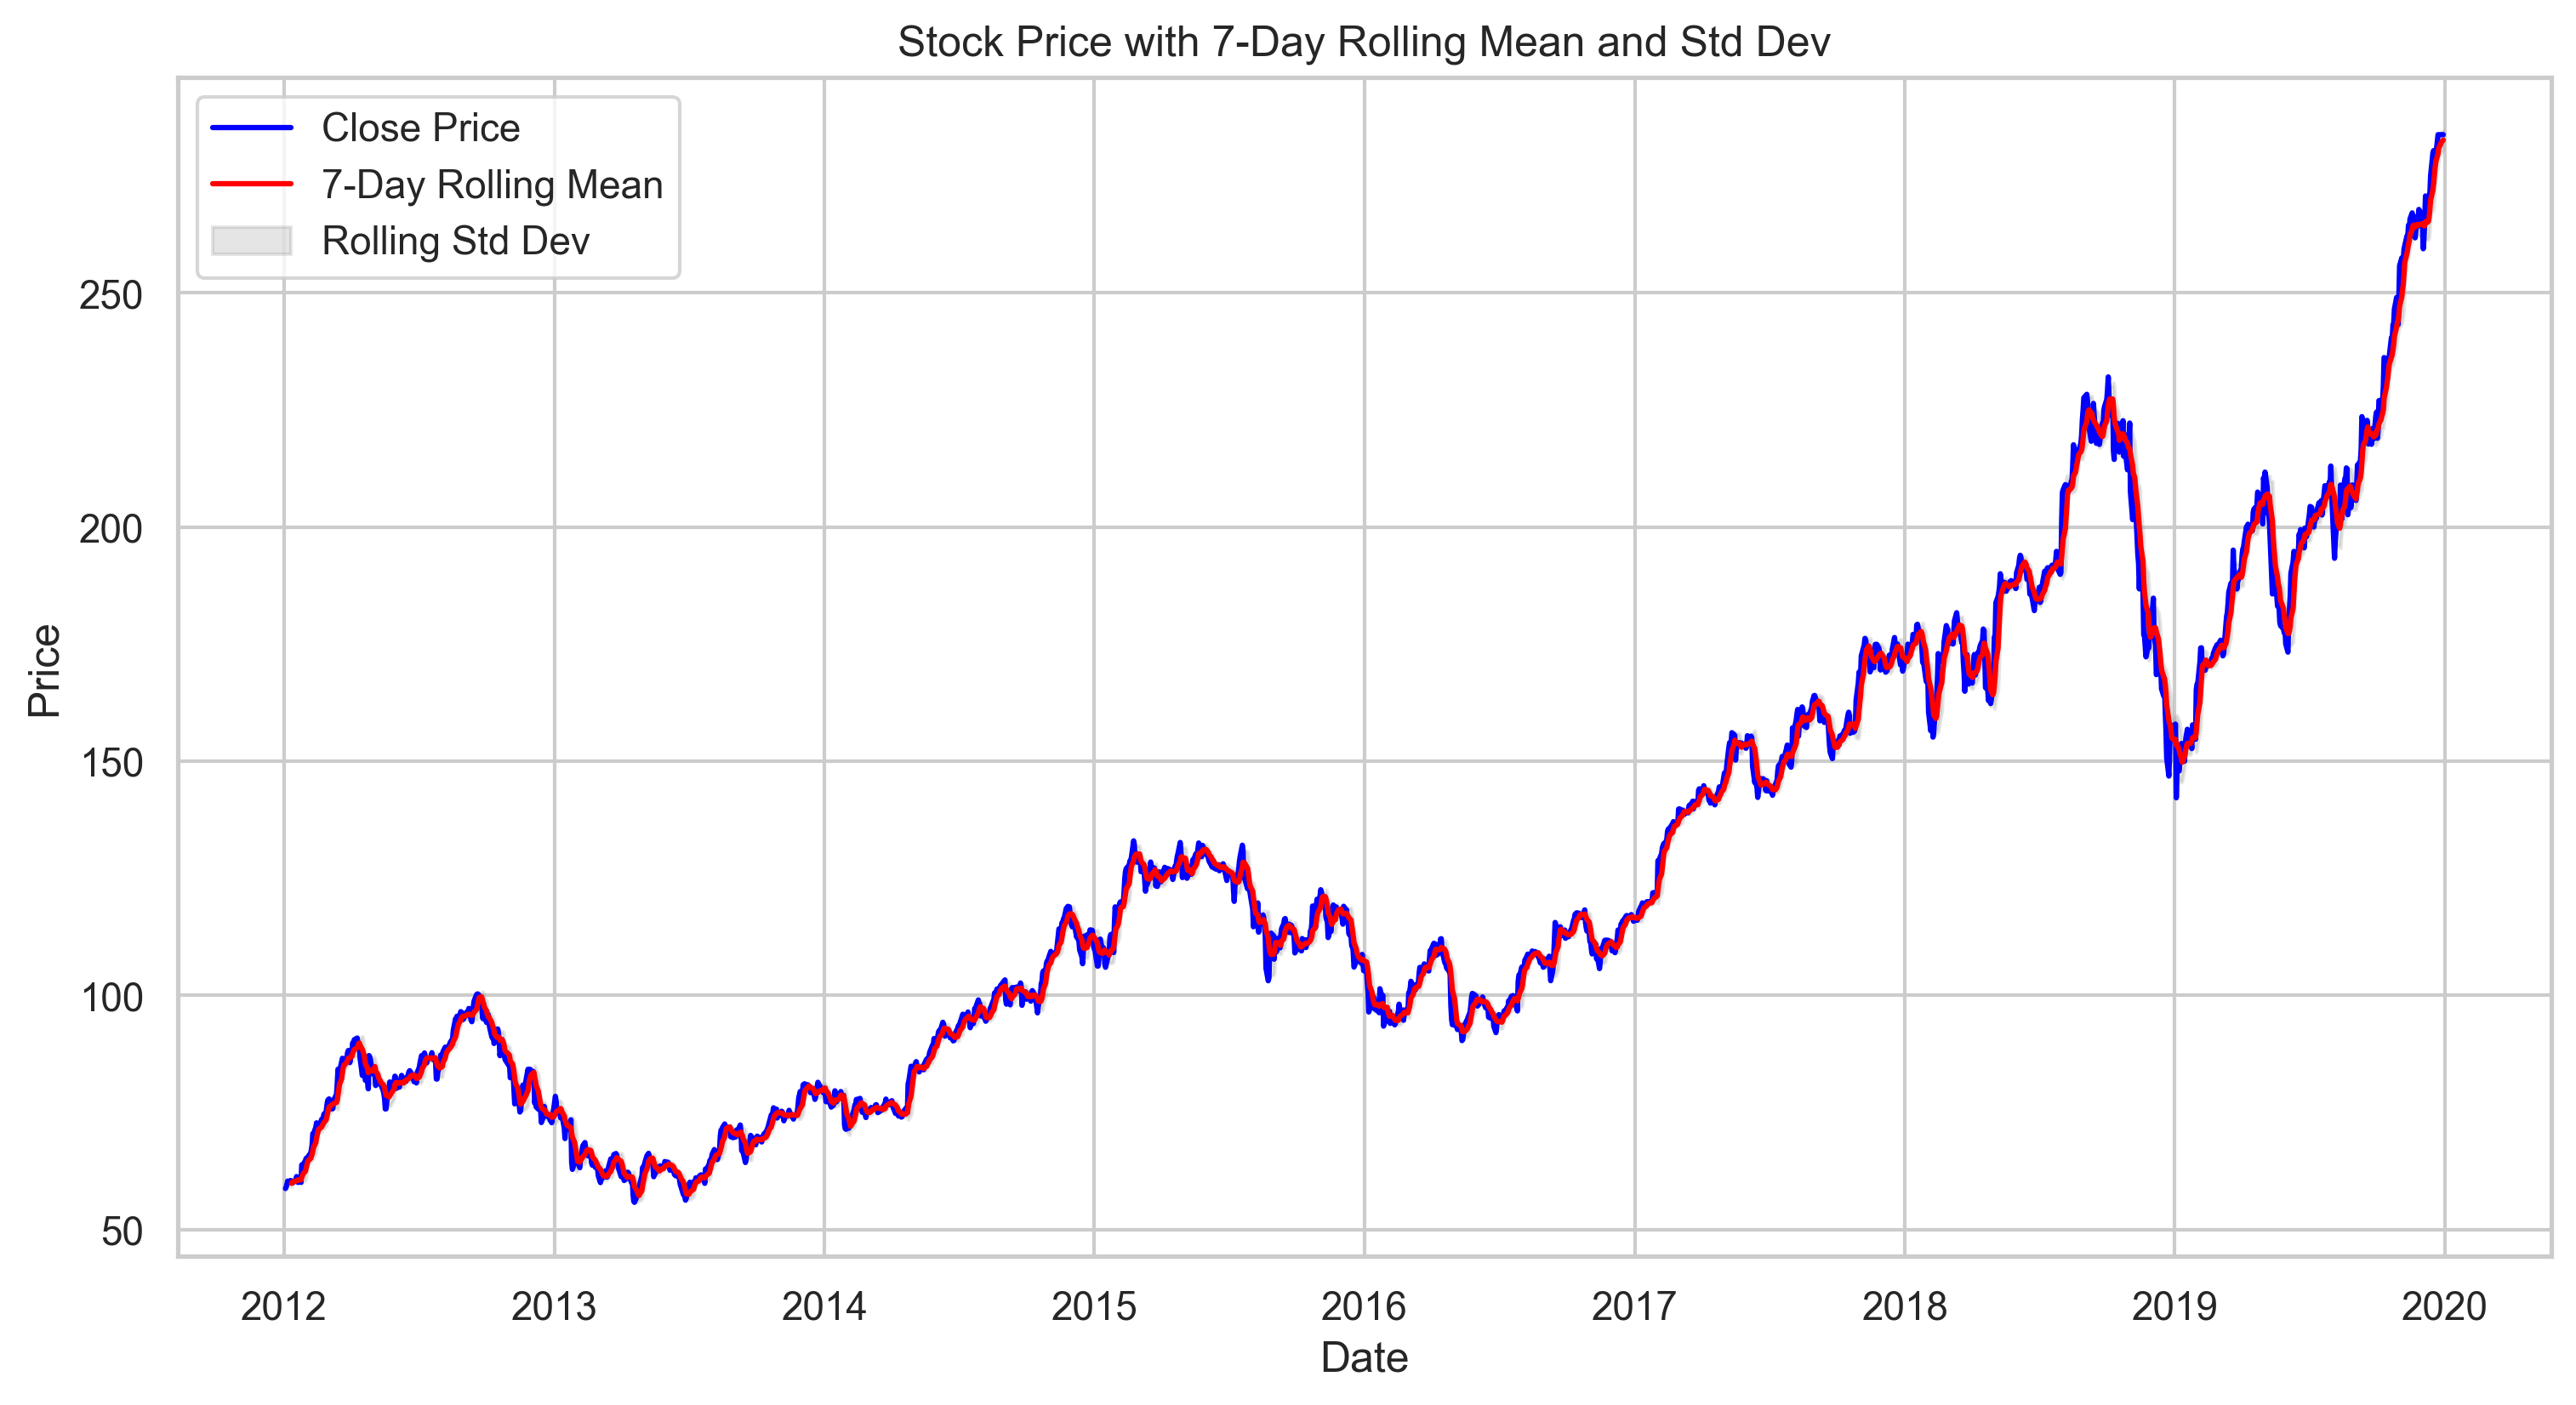

In [55]:
# Plot the rolling statistics with the original series
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Close Price', color='blue')
plt.plot(df.index, df['rolling_mean_7'], label='7-Day Rolling Mean', color='red')
plt.fill_between(df.index,
                 df['rolling_mean_7'] - df['rolling_std_7'],
                 df['rolling_mean_7'] + df['rolling_std_7'],
                 color='gray', alpha=0.2, label='Rolling Std Dev')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Stock Price with 7-Day Rolling Mean and Std Dev')
plt.legend()
plt.show()

In [56]:
def evaluate_forecast(y_true, y_pred):
    """
    Evaluate forecast using common metrics.
    """
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print("\nEvaluation Metrics:")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)

In [57]:
#Save Processed Data
df.to_csv('processed_stock_data.csv')
print("\nEDA complete. Processed data saved to 'processed_stock_data.csv'.")


EDA complete. Processed data saved to 'processed_stock_data.csv'.
